# Baseline Model

This notebook documents the first complete end-to-end modeling experiment for Dental X-ray pathology detection. The baseline is not intended to establish the final architecture. It verifies that the prepared DENTEX data, training lifecycle, validation protocol, checkpoint handling, and diagnostic analysis operate as one reproducible system. The resulting persisted model provides the empirical reference against which later architecture and refinement experiments are compared.

The experiment trains only on the training subset and evaluates model behavior on the validation subset. The test subset is excluded from model fitting, validation-driven selection, hyperparameter tuning, and baseline inference. Structural annotation checks may still inspect test metadata as part of dataset integrity validation.

## 1. Baseline Objective and Role

A baseline establishes the minimum empirical reference required to judge whether later changes actually improve the system. Without it, changes in architecture, preprocessing, augmentation, resolution, or optimization cannot be separated from ordinary experimental variation.

YOLO26n was selected as a practical starting detector because pretrained initialization and the Ultralytics training and validation tooling make it possible to exercise the complete pipeline quickly and reproducibly. This choice does not assume that YOLO is the best detector for the task. Its role is to expose data and modeling weaknesses early, quantify the initial performance level, identify weak classes, and generate testable hypotheses for controlled model comparison.

## 2. Baseline Architecture — Conceptual View

The detector can be understood at the level needed for this experiment as the following sequence:

$$
\text{image} \rightarrow \text{feature extraction} \rightarrow \text{multi-scale feature representation}
\rightarrow \text{detection head} \rightarrow (\text{boxes},\ \text{classes},\ \text{confidence scores}).
$$

The multi-scale representation is relevant because dental findings vary considerably in spatial extent. The detection head predicts locations and one of four project classes: **Impacted**, **Caries**, **Periapical Lesion**, or **Deep Caries**. This conceptual description is sufficient for interpreting the baseline; detailed architectural comparison belongs to the screening stage.

## 3. Dataset and Split Integrity Before Training

The notebook first resolves the project paths and records the software and hardware environment. Fixed random seeds reduce avoidable variation across repeated executions.

In [1]:
from dataclasses import asdict, dataclass
import hashlib
import json
import platform
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from PIL import Image
import torch
from tqdm.auto import tqdm
import ultralytics
from ultralytics import YOLO

C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclass(frozen=True)
class BaselineConfig:
    random_seed: int = 42
    model_name: str = "yolo26n.pt"
    image_size: int = 640
    epochs: int = 20
    batch_size: int = 4
    device: int | str = 0
    workers: int = 0
    patience: int = 5
    save_period: int = 1
    training_mode: str = "resume"
    run_name: str = "yolo26n_640_seed42"


@dataclass(frozen=True)
class AugmentationConfig:
    degrees: float = 5.0
    translate: float = 0.03
    scale: float = 0.08
    fliplr: float = 0.0
    flipud: float = 0.0
    hsv_h: float = 0.0
    hsv_s: float = 0.0
    hsv_v: float = 0.10
    mosaic: float = 0.0
    mixup: float = 0.0
    cutmix: float = 0.0


@dataclass(frozen=True)
class ProjectPaths:
    project_root: Path
    canonical_root: Path
    yolo_root: Path
    data_yaml: Path
    artifact_root: Path
    run_dir: Path
    metrics_dir: Path


def resolve_project_paths(run_name: str) -> ProjectPaths:
    """Resolve all dataset and experiment paths from the current location."""
    current_directory = Path.cwd().resolve()
    candidate_root = current_directory

    if not (candidate_root / "data" / "processed" / "dentex_diagnosis").is_dir():
        candidate_root = current_directory.parent

    canonical_root = candidate_root / "data" / "processed" / "dentex_diagnosis"
    yolo_root = candidate_root / "data" / "model_ready" / "dentex_yolo"
    artifact_root = candidate_root / "artifacts" / "baseline"
    run_dir = artifact_root / run_name

    return ProjectPaths(
        project_root=candidate_root,
        canonical_root=canonical_root,
        yolo_root=yolo_root,
        data_yaml=yolo_root / "data.yaml",
        artifact_root=artifact_root,
        run_dir=run_dir,
        metrics_dir=artifact_root / "metrics",
    )


CONFIG = BaselineConfig()
AUGMENTATION = AugmentationConfig()
PATHS = resolve_project_paths(CONFIG.run_name)

CLASS_NAMES = {
    0: "Impacted",
    1: "Caries",
    2: "Periapical Lesion",
    3: "Deep Caries",
}

def require_yolo_materialization(paths: ProjectPaths) -> None:
    """Fail clearly when the on-demand historical YOLO view is absent."""
    required = [
        paths.data_yaml,
        *(paths.yolo_root / "images" / split for split in ("train", "val", "test")),
        *(paths.yolo_root / "labels" / split for split in ("train", "val", "test")),
    ]
    missing = [path for path in required if not path.exists()]
    if missing:
        missing_text = "\n- ".join(str(path) for path in missing)
        raise FileNotFoundError(
            "The historical YOLO dataset representation is not materialized. "
            "Run section '9. Canonical COCO to YOLO Annotation Conversion' in "
            "notebooks/02_preprocessing.ipynb, then rerun this notebook. "
            "Notebook 03 does not rebuild derived data automatically."
            f"\nMissing paths:\n- {missing_text}"
        )


require_yolo_materialization(PATHS)

if CONFIG.training_mode not in {"new", "resume"}:
    raise ValueError("training_mode must be either 'new' or 'resume'")

display(pd.Series({**asdict(CONFIG), **asdict(AUGMENTATION)}, name="value").to_frame())
display(pd.Series({key: str(value) for key, value in asdict(PATHS).items()}, name="path").to_frame())

,value
random_seed,42
model_name,yolo26n.pt
image_size,640
epochs,20
batch_size,4
device,0
workers,0
patience,5
save_period,1
training_mode,resume


,path
project_root,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
canonical_root,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
yolo_root,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
data_yaml,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
artifact_root,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
run_dir,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
metrics_dir,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...


In [3]:
def inspect_environment() -> tuple[pd.DataFrame, bool]:
    """Report runtime versions and whether the configured CUDA device is usable."""
    cuda_available = torch.cuda.is_available()
    gpu_name = "Unavailable"
    gpu_memory_gib = None

    if cuda_available:
        gpu_index = int(CONFIG.device)
        gpu_name = torch.cuda.get_device_name(gpu_index)
        gpu_properties = torch.cuda.get_device_properties(gpu_index)
        gpu_memory_gib = gpu_properties.total_memory / (1024**3)

    environment = pd.Series(
        {
            "Python": platform.python_version(),
            "PyTorch": torch.__version__,
            "Ultralytics": ultralytics.__version__,
            "PyTorch CUDA runtime": torch.version.cuda or "Unavailable",
            "CUDA available": cuda_available,
            "Configured device": CONFIG.device,
            "GPU": gpu_name,
            "GPU memory (GiB)": gpu_memory_gib,
        },
        name="value",
    ).to_frame()

    training_available = cuda_available
    status = "available" if training_available else "unavailable"
    print(f"[GPU] Training is {status}: {gpu_name}")
    return environment, training_available


environment_report, TRAINING_AVAILABLE = inspect_environment()
display(environment_report)

[GPU] Training is available: NVIDIA GeForce RTX 3050 Laptop GPU


,value
Python,3.13.5
PyTorch,2.11.0+cu128
Ultralytics,8.4.143
PyTorch CUDA runtime,12.8
CUDA available,True
Configured device,0
GPU,NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory (GiB),3.999512


In [4]:
def set_reproducibility(seed: int) -> None:
    """Seed Python, NumPy, and PyTorch and configure deterministic cuDNN behavior."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[REPRODUCIBILITY] Seed set to {seed}")


set_reproducibility(CONFIG.random_seed)

[REPRODUCIBILITY] Seed set to 42


Before model construction, fail-fast checks verify image/label correspondence, split membership, missing files, malformed label rows, class-ID bounds, normalized coordinates, positive box dimensions, and the intentional representation of negative images by empty label files. Silent repair is avoided because it can change the scientific object being evaluated while hiding upstream data defects.

The same checks cover train, validation, and test directory structure. Reading test annotations here establishes structural integrity only; it does not perform inference, compute test metrics, select a model, or tune a decision threshold.

In [5]:
def validate_yolo_dataset(
    canonical_root: Path,
    yolo_root: Path,
) -> pd.DataFrame:
    """Validate image membership and every model-ready YOLO label row."""
    validation_rows = []

    for split in ("train", "val", "test"):
        annotation_path = canonical_root / "annotations" / f"{split}.json"
        canonical_payload = json.loads(annotation_path.read_text(encoding="utf-8"))
        expected_images = {record["file_name"] for record in canonical_payload["images"]}

        image_directory = yolo_root / "images" / split
        label_directory = yolo_root / "labels" / split
        actual_images = {path.name for path in image_directory.glob("*.png")}
        label_paths = sorted(label_directory.glob("*.txt"))

        expected_labels = {
            Path(file_name).with_suffix(".txt").name
            for file_name in expected_images
        }
        actual_labels = {path.name for path in label_paths}

        malformed_rows = []
        observed_classes = set()
        object_count = 0
        empty_label_count = 0

        for label_path in tqdm(
            label_paths,
            desc=f"Validating {split}",
            unit="label",
        ):
            label_lines = label_path.read_text(encoding="utf-8").splitlines()
            if not label_lines:
                empty_label_count += 1

            for line_number, line in enumerate(label_lines, start=1):
                fields = line.split()
                object_count += 1

                if len(fields) != 5:
                    malformed_rows.append((label_path.name, line_number, line))
                    continue

                class_value, *coordinates = map(float, fields)
                class_id = int(class_value)
                observed_classes.add(class_id)

                valid_class = class_value == class_id and class_id in CLASS_NAMES
                valid_coordinates = all(0.0 <= value <= 1.0 for value in coordinates)
                positive_size = coordinates[2] > 0.0 and coordinates[3] > 0.0

                if not (valid_class and valid_coordinates and positive_size):
                    malformed_rows.append((label_path.name, line_number, line))

        missing_images = expected_images - actual_images
        unexpected_images = actual_images - expected_images
        missing_labels = expected_labels - actual_labels
        unexpected_labels = actual_labels - expected_labels

        validation_rows.append(
            {
                "split": split,
                "canonical_images": len(expected_images),
                "yolo_images": len(actual_images),
                "label_files": len(label_paths),
                "objects": object_count,
                "empty_labels": empty_label_count,
                "missing_images": len(missing_images),
                "unexpected_images": len(unexpected_images),
                "missing_labels": len(missing_labels),
                "unexpected_labels": len(unexpected_labels),
                "malformed_rows": len(malformed_rows),
                "class_ids": sorted(observed_classes),
            }
        )

    report = pd.DataFrame(validation_rows)
    error_columns = [
        "missing_images",
        "unexpected_images",
        "missing_labels",
        "unexpected_labels",
        "malformed_rows",
    ]
    has_errors = report[error_columns].to_numpy().sum() > 0
    has_unexpected_classes = any(ids != [0, 1, 2, 3] for ids in report["class_ids"])

    if has_errors or has_unexpected_classes:
        raise RuntimeError("Model-ready dataset validation failed; inspect the report")

    print("[DATA] Validation passed")
    return report

In [6]:
dataset_report = validate_yolo_dataset(
    canonical_root=PATHS.canonical_root,
    yolo_root=PATHS.yolo_root,
)
display(dataset_report)

Validating train:   0%|          | 0/493 [00:00<?, ?label/s]

Validating train:  73%|███████▎  | 362/493 [00:00<00:00, 3611.90label/s]

Validating train: 100%|██████████| 493/493 [00:00<00:00, 3475.97label/s]

Validating val:   0%|          | 0/106 [00:00<?, ?label/s]

Validating val: 100%|██████████| 106/106 [00:00<00:00, 2242.38label/s]

Validating test:   0%|          | 0/106 [00:00<?, ?label/s]

Validating test: 100%|██████████| 106/106 [00:00<00:00, 2464.48label/s]

[DATA] Validation passed


,split,canonical_images,yolo_images,label_files,objects,empty_labels,missing_images,unexpected_images,missing_labels,unexpected_labels,malformed_rows,class_ids
0,train,493,493,493,2442,19,0,0,0,0,0,"[0, 1, 2, 3]"
1,val,106,106,106,548,4,0,0,0,0,0,"[0, 1, 2, 3]"
2,test,106,106,106,539,4,0,0,0,0,0,"[0, 1, 2, 3]"


In [7]:
def read_yolo_labels(label_path: Path, width: int, height: int) -> list[dict]:
    """Decode normalized YOLO rows into pixel-space boxes."""
    boxes = []

    for line in label_path.read_text(encoding="utf-8").splitlines():
        class_value, x_center, y_center, box_width, box_height = map(float, line.split())
        pixel_width = box_width * width
        pixel_height = box_height * height

        boxes.append(
            {
                "class_id": int(class_value),
                "x": (x_center - box_width / 2) * width,
                "y": (y_center - box_height / 2) * height,
                "width": pixel_width,
                "height": pixel_height,
                "relative_area": box_width * box_height,
            }
        )

    return boxes


def select_sanity_examples(yolo_root: Path) -> list[tuple[str, Path, list[dict]]]:
    """Scan training labels and select deterministic representative examples."""
    image_directory = yolo_root / "images" / "train"
    label_directory = yolo_root / "labels" / "train"
    records = []

    image_paths = sorted(image_directory.glob("*.png"))
    for image_path in tqdm(image_paths, desc="Scanning train examples", unit="image"):
        with Image.open(image_path) as image:
            width, height = image.size

        label_path = label_directory / image_path.with_suffix(".txt").name
        boxes = read_yolo_labels(label_path, width, height)
        records.append((image_path, boxes))

    object_counts = np.array([len(boxes) for _, boxes in records])
    median_count = np.median(object_counts)
    typical_index = int(np.argmin(np.abs(object_counts - median_count)))
    dense_index = int(np.argmax(object_counts))

    non_empty_records = [record for record in records if record[1]]
    small_record = min(
        non_empty_records,
        key=lambda record: min(box["relative_area"] for box in record[1]),
    )
    minority_record = next(
        record
        for record in records
        if any(box["class_id"] == 2 for box in record[1])
    )
    negative_record = next(record for record in records if not record[1])

    return [
        ("Typical", *records[typical_index]),
        ("Dense / multi-object", *records[dense_index]),
        ("Small-object", *small_record),
        ("Minority class", *minority_record),
        ("Negative", *negative_record),
    ]


def plot_detection_annotations(
    examples: list[tuple[str, Path, list[dict]]],
) -> None:
    """Plot decoded YOLO boxes on model-ready images."""
    figure, axes = plt.subplots(len(examples), 1, figsize=(15, 4 * len(examples)))

    for axis, (example_name, image_path, boxes) in zip(axes, examples):
        image = np.array(Image.open(image_path).convert("L"))
        axis.imshow(image, cmap="gray")

        for box in boxes:
            class_id = box["class_id"]
            axis.add_patch(
                Rectangle(
                    (box["x"], box["y"]),
                    box["width"],
                    box["height"],
                    fill=False,
                    linewidth=1.5,
                    color=f"C{class_id}",
                )
            )
            axis.text(
                box["x"],
                max(0, box["y"] - 4),
                CLASS_NAMES[class_id],
                color="white",
                fontsize=7,
                bbox={"facecolor": f"C{class_id}", "alpha": 0.8, "pad": 1},
            )

        height, width = image.shape
        axis.set_title(
            f"{example_name} — {image_path.name} — "
            f"{width}×{height} — {len(boxes)} objects"
        )
        axis.axis("off")

    plt.tight_layout()
    plt.show()

Scanning train examples:   0%|          | 0/493 [00:00<?, ?image/s]

Scanning train examples:  23%|██▎       | 111/493 [00:00<00:00, 1109.19image/s]

Scanning train examples:  45%|████▌     | 222/493 [00:00<00:00, 1066.95image/s]

Scanning train examples:  70%|██████▉   | 344/493 [00:00<00:00, 1133.78image/s]

Scanning train examples:  93%|█████████▎| 458/493 [00:00<00:00, 1075.82image/s]

Scanning train examples: 100%|██████████| 493/493 [00:00<00:00, 1050.58image/s]

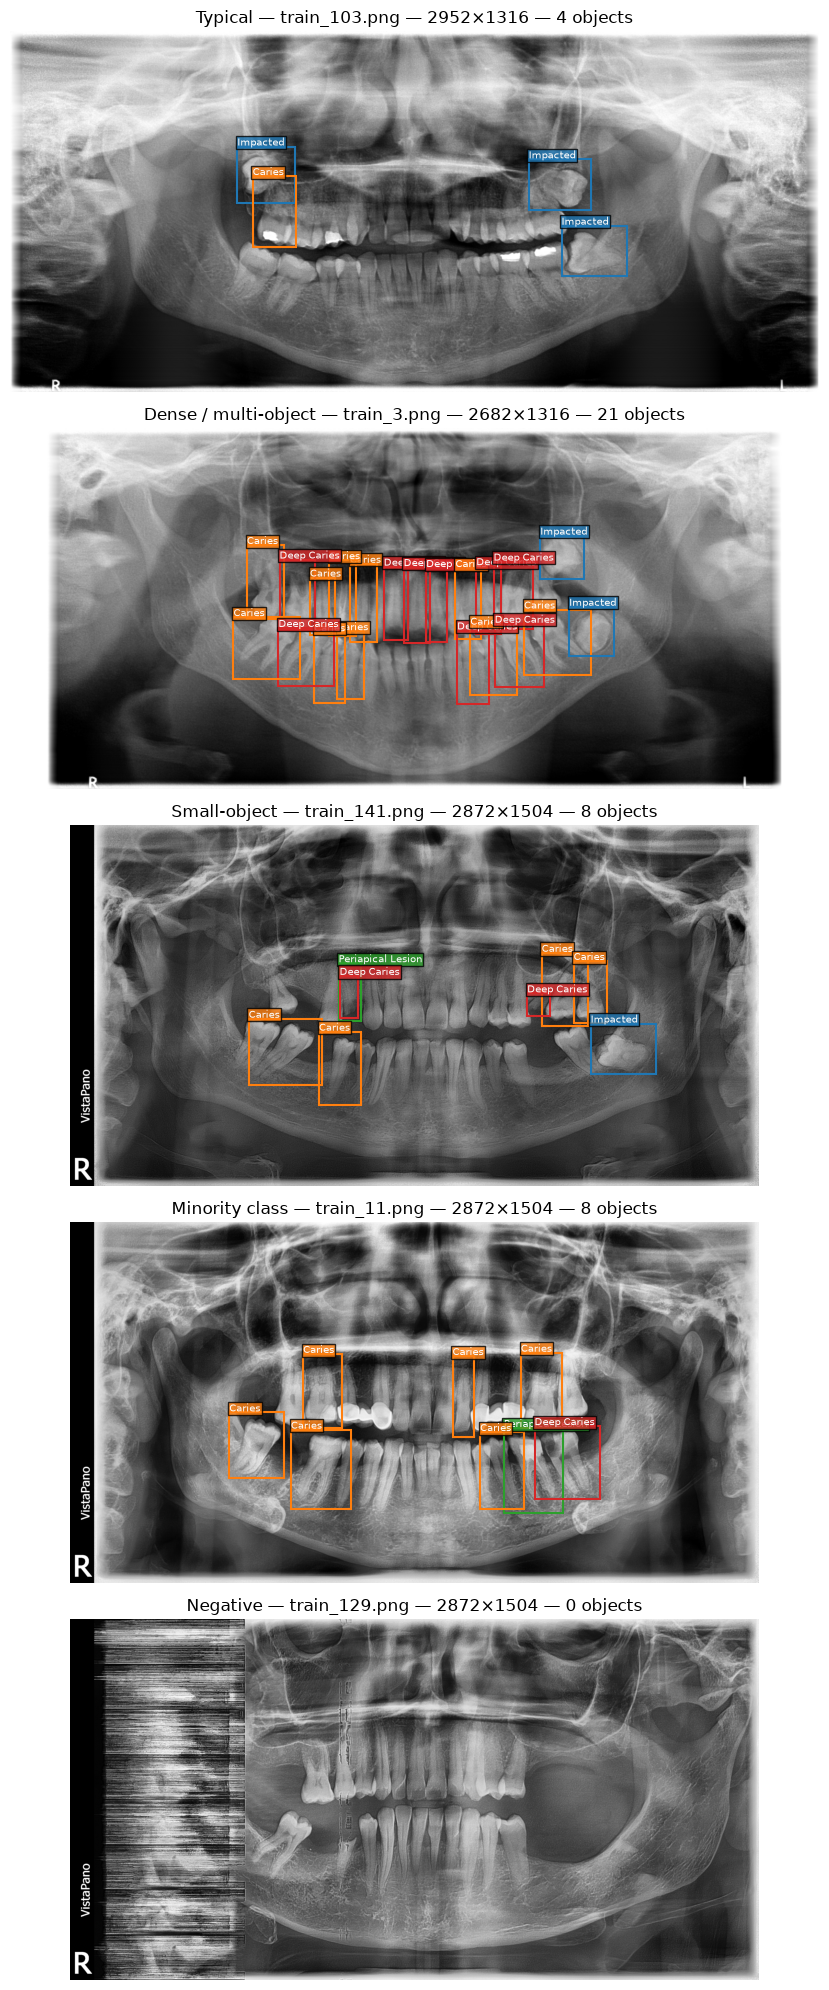

In [8]:
sanity_examples = select_sanity_examples(PATHS.yolo_root)
plot_detection_annotations(sanity_examples)

In [9]:
def hash_file(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file_handle:
        while chunk := file_handle.read(1024 * 1024):
            digest.update(chunk)

    return digest.hexdigest()


def snapshot_dataset_integrity(
    canonical_root: Path,
    yolo_root: Path,
) -> dict:
    """Capture canonical hashes and current YOLO split membership once."""
    canonical_files = sorted(path for path in canonical_root.rglob("*") if path.is_file())
    canonical_hashes = {}

    for file_path in tqdm(canonical_files, desc="Hashing canonical dataset", unit="file"):
        relative_path = str(file_path.relative_to(canonical_root))
        canonical_hashes[relative_path] = hash_file(file_path)

    split_membership = {
        split: tuple(sorted(path.name for path in (yolo_root / "images" / split).glob("*.png")))
        for split in ("train", "val", "test")
    }

    return {
        "canonical_hashes": canonical_hashes,
        "split_membership": split_membership,
    }

In [10]:
integrity_snapshot_before = snapshot_dataset_integrity(
    canonical_root=PATHS.canonical_root,
    yolo_root=PATHS.yolo_root,
)
print("[INTEGRITY] Pre-training snapshot captured")

Hashing canonical dataset:   0%|          | 0/709 [00:00<?, ?file/s]

Hashing canonical dataset:   2%|▏         | 12/709 [00:00<00:06, 113.88file/s]

Hashing canonical dataset:   3%|▎         | 24/709 [00:00<00:06, 100.32file/s]

Hashing canonical dataset:   5%|▍         | 35/709 [00:00<00:06, 96.64file/s] 

Hashing canonical dataset:   6%|▋         | 46/709 [00:00<00:06, 96.83file/s]

...

Hashing canonical dataset:  96%|█████████▋| 683/709 [00:07<00:00, 104.39file/s]

Hashing canonical dataset:  98%|█████████▊| 695/709 [00:07<00:00, 107.68file/s]

Hashing canonical dataset: 100%|█████████▉| 708/709 [00:07<00:00, 111.46file/s]

Hashing canonical dataset: 100%|██████████| 709/709 [00:07<00:00, 94.02file/s] 

[INTEGRITY] Pre-training snapshot captured


**Interpretation.** The validated split is the fixed experimental boundary: training observations update model parameters, validation observations support analysis and checkpoint selection, and test metadata is limited to structural checks at this stage.

## 4. Training Configuration

The canonical baseline uses pretrained `yolo26n.pt` weights, an input size of $640\times640$, 20 epochs, batch size 4, device 0, zero data-loader workers, seed 42, early-stopping patience 5, and an epoch checkpoint period of 1. `optimizer="auto"` delegates selection of the concrete optimizer and related optimization settings to Ultralytics; the baseline therefore does not claim a manually fixed initial learning rate.

The deliberately modest configuration provides a reproducible reference within practical compute limits. It is not presented as a fully optimized regime.

In [11]:
def build_training_arguments(
    config: BaselineConfig,
    augmentation: AugmentationConfig,
    paths: ProjectPaths,
) -> dict:
    """Build the explicit arguments for a new baseline run."""
    return {
        "data": str(paths.data_yaml),
        "imgsz": config.image_size,
        "epochs": config.epochs,
        "batch": config.batch_size,
        "device": config.device,
        "workers": config.workers,
        "seed": config.random_seed,
        "deterministic": True,
        "patience": config.patience,
        "save": True,
        "save_period": config.save_period,
        "project": str(paths.artifact_root),
        "name": config.run_name,
        "exist_ok": True,
        "optimizer": "auto",
        "plots": True,
        "verbose": True,
        **asdict(augmentation),
    }


training_arguments = build_training_arguments(CONFIG, AUGMENTATION, PATHS)
display(pd.Series(training_arguments, name="value").to_frame())

,value
data,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
imgsz,640
epochs,20
batch,4
device,0
workers,0
seed,42
deterministic,True
patience,5
save,True


## 5. Baseline Augmentation Policy

Training uses only conservative transformations compatible with panoramic dental radiographs: rotation up to $\pm5^\circ$, translation up to 3%, scale variation up to 8%, and mild brightness variation (`hsv_v=0.10`). Horizontal and vertical flips are disabled because they can alter clinically meaningful orientation. Mosaic, MixUp, and CutMix are also disabled, keeping the first reference experiment easy to interpret.

Validation remains deterministic and does not use stochastic training augmentation. These choices define the baseline configuration only; they do not establish the final augmentation policy.

## 6. Experiment Lifecycle and Reproducibility

The experiment lifecycle distinguishes four operations: starting a genuinely new run, resuming an interrupted run, loading existing artifacts, and validating a persisted checkpoint. The existing run directory is treated as completed or resumable evidence, not as disposable notebook state.

`last.pt` records the latest state reached by training and retains the native optimizer/training state required for resume. `best.pt` is the checkpoint selected by the framework according to validation performance and is therefore the artifact used for final baseline analysis. Artifact discovery is performed before any manual training action.

In [12]:
def get_checkpoint_state(run_dir: Path) -> dict:
    """Return a readable snapshot of native Ultralytics artifacts."""
    weights_directory = run_dir / "weights"
    last_path = weights_directory / "last.pt"
    best_path = weights_directory / "best.pt"
    results_path = run_dir / "results.csv"
    epoch_checkpoints = sorted(weights_directory.glob("epoch*.pt"))

    return {
        "last_exists": last_path.is_file(),
        "best_exists": best_path.is_file(),
        "results_csv_exists": results_path.is_file(),
        "last_path": last_path,
        "best_path": best_path,
        "results_csv_path": results_path,
        "periodic_checkpoints": epoch_checkpoints,
    }


def print_checkpoint_state(state: dict, training_mode: str) -> None:
    """Print the exact start or resume action before training."""
    print(f"[TRAIN] Mode: {training_mode.upper()}")

    if training_mode == "resume":
        print(f"[CHECKPOINT] Resume checkpoint: {state['last_path']}")
    else:
        print(f"[CHECKPOINT] Initial pretrained weights: {CONFIG.model_name}")

    print(f"[CHECKPOINT] last.pt found: {state['last_exists']}")
    print(f"[CHECKPOINT] best.pt found: {state['best_exists']}")
    print(f"[CHECKPOINT] results.csv found: {state['results_csv_exists']}")
    print(f"[CHECKPOINT] periodic checkpoints: {len(state['periodic_checkpoints'])}")


checkpoint_state = get_checkpoint_state(PATHS.run_dir)
print_checkpoint_state(checkpoint_state, CONFIG.training_mode)

def inspect_run_artifacts(run_dir: Path, metrics_dir: Path) -> pd.DataFrame:
    """Summarize persistent experiment artifacts after a kernel restart."""
    results_path = run_dir / "results.csv"
    history = load_history = None
    completed_epochs = 0
    best_epoch = None

    if results_path.is_file():
        load_history = pd.read_csv(results_path)
        load_history.columns = [column.strip() for column in load_history.columns]
        completed_epochs = len(load_history)
        metric_column = "metrics/mAP50-95(B)"
        if metric_column in load_history.columns:
            best_epoch = int(load_history.loc[load_history[metric_column].idxmax(), "epoch"])

    plot_names = sorted(plot.name for plot in run_dir.glob("*.png"))
    metrics_path = metrics_dir / f"{CONFIG.run_name}_metrics.json"
    return pd.DataFrame([{
        "run_name": CONFIG.run_name,
        "results_csv": results_path.is_file(),
        "best_pt": (run_dir / "weights" / "best.pt").is_file(),
        "last_pt": (run_dir / "weights" / "last.pt").is_file(),
        "completed_epochs": completed_epochs,
        "best_epoch": best_epoch,
        "periodic_checkpoints": len(list((run_dir / "weights").glob("epoch*.pt"))),
        "framework_plots": len(plot_names),
        "saved_metrics_json": metrics_path.is_file(),
    }])


artifact_report = inspect_run_artifacts(PATHS.run_dir, PATHS.metrics_dir)
display(artifact_report.style.format({"completed_epochs": "{:.0f}", "best_epoch": "{:.0f}"}))

[TRAIN] Mode: RESUME
[CHECKPOINT] Resume checkpoint: C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\baseline\yolo26n_640_seed42\weights\last.pt
[CHECKPOINT] last.pt found: True
[CHECKPOINT] best.pt found: True
[CHECKPOINT] results.csv found: True
[CHECKPOINT] periodic checkpoints: 12


,run_name,results_csv,best_pt,last_pt,completed_epochs,best_epoch,periodic_checkpoints,framework_plots,saved_metrics_json
0,yolo26n_640_seed42,True,True,True,20,18,12,7,True


The following cell is intentionally manual. It can resume only from an existing run checkpoint, explicitly overrides checkpoint dataset metadata with the DENTEX `data.yaml`, prints the checkpoint, dataset, run directory, and mode, and blocks automatic overwrite or fresh training.

In [ ]:
# MANUAL EXECUTION — RESUME TRAINING
# This cell is intentionally not executed automatically.

def inspect_checkpoint_resume_state(path: Path) -> dict:
    """Inspect native Ultralytics state without constructing a YOLO trainer."""
    path = Path(path).resolve()
    state = {
        "path": path,
        "exists": path.is_file(),
        "epoch": None,
        "optimizer_present": False,
        "train_args_present": False,
        "model_present": False,
        "ema_present": False,
        "date": None,
        "version": None,
        "resumable": False,
        "reason": "Checkpoint file does not exist.",
        "train_args": {},
    }
    if not state["exists"]:
        return state

    checkpoint = torch.load(path, map_location="cpu", weights_only=False)
    if not isinstance(checkpoint, dict):
        state["reason"] = "Checkpoint payload is not an Ultralytics checkpoint dictionary."
        return state

    train_args = checkpoint.get("train_args")
    state.update(
        epoch=checkpoint.get("epoch"),
        optimizer_present=checkpoint.get("optimizer") is not None,
        train_args_present=isinstance(train_args, dict) and bool(train_args),
        model_present=checkpoint.get("model") is not None,
        ema_present=checkpoint.get("ema") is not None,
        date=checkpoint.get("date"),
        version=checkpoint.get("version"),
        train_args=train_args if isinstance(train_args, dict) else {},
    )

    missing = []
    if not isinstance(state["epoch"], int) or state["epoch"] < 0:
        missing.append("valid epoch")
    if not state["optimizer_present"]:
        missing.append("optimizer state")
    if not state["train_args_present"]:
        missing.append("training arguments")
    if not (state["model_present"] or state["ema_present"]):
        missing.append("model/EMA state")

    state["resumable"] = not missing
    state["reason"] = "Resume state is complete." if not missing else "Missing " + ", ".join(missing) + "."
    return state


def select_resume_checkpoint(weights_dir: Path) -> tuple[dict, list[dict]]:
    """Prefer valid last.pt; otherwise select the latest stateful epoch checkpoint."""
    weights_dir = Path(weights_dir).resolve()
    epoch_paths = sorted(
        weights_dir.glob("epoch*.pt"),
        key=lambda candidate: int(candidate.stem.removeprefix("epoch")),
        reverse=True,
    )
    paths = [weights_dir / "last.pt", weights_dir / "best.pt", *epoch_paths]
    inspections = [inspect_checkpoint_resume_state(candidate) for candidate in paths]

    for state in inspections:
        status = "resumable" if state["resumable"] else f"not resumable: {state['reason']}"
        print(f"[CHECKPOINT] {state['path'].name}: {status}")

    last_state = inspections[0]
    if last_state["resumable"]:
        return last_state, inspections

    periodic_candidates = [state for state in inspections[2:] if state["resumable"]]
    if periodic_candidates:
        return max(periodic_candidates, key=lambda state: state["epoch"]), inspections

    raise RuntimeError(
        "No resumable optimizer checkpoint exists. Existing best.pt can still be used "
        "for evaluation and post-training analysis, but continuation of the original "
        "optimizer trajectory is unavailable. Fresh training has been blocked."
    )


if not TRAINING_AVAILABLE:
    raise RuntimeError(
        "Ultralytics/CUDA training is unavailable. Fresh-training fallback is blocked."
    )
if CONFIG.training_mode != "resume":
    raise RuntimeError("Only manual resume mode is permitted in this cell.")

dataset_yaml = PATHS.data_yaml.resolve()
run_directory = PATHS.run_dir.resolve()
weights_directory = run_directory / "weights"

if not dataset_yaml.is_file():
    raise FileNotFoundError(f"DENTEX dataset YAML was not found: {dataset_yaml}")
if not weights_directory.is_dir():
    raise FileNotFoundError(f"Existing baseline weights directory was not found: {weights_directory}")

selected_checkpoint, checkpoint_inspections = select_resume_checkpoint(weights_directory)
if not selected_checkpoint["resumable"]:
    raise RuntimeError("Checkpoint is not resumable. Fresh training has been blocked.")

stored_args = selected_checkpoint["train_args"]
expected_args = {
    "epochs": CONFIG.epochs,
    "batch": CONFIG.batch_size,
    "imgsz": CONFIG.image_size,
    "workers": CONFIG.workers,
    "seed": CONFIG.random_seed,
    "deterministic": True,
    "amp": True,
    "save_period": CONFIG.save_period,
    "patience": CONFIG.patience,
    "mosaic": AUGMENTATION.mosaic,
    "mixup": AUGMENTATION.mixup,
    "fliplr": AUGMENTATION.fliplr,
    "flipud": AUGMENTATION.flipud,
    "degrees": AUGMENTATION.degrees,
    "translate": AUGMENTATION.translate,
    "scale": AUGMENTATION.scale,
    "hsv_v": AUGMENTATION.hsv_v,
    "name": CONFIG.run_name,
    "optimizer": "auto",
}
configuration_mismatches = {
    key: {"checkpoint": stored_args.get(key), "expected": expected}
    for key, expected in expected_args.items()
    if stored_args.get(key) != expected
}
if configuration_mismatches:
    raise RuntimeError(
        "Checkpoint training arguments do not match the original baseline configuration: "
        f"{configuration_mismatches}. Fresh training has been blocked."
    )

stored_project = Path(str(stored_args.get("project", ""))).resolve()
if stored_project != PATHS.artifact_root.resolve():
    raise RuntimeError(
        f"Checkpoint project directory is {stored_project}, not {PATHS.artifact_root.resolve()}. "
        "Resume has been blocked."
    )

stored_dataset = stored_args.get("data")
if stored_dataset and Path(str(stored_dataset)).resolve() != dataset_yaml:
    print(
        "[WARNING] Checkpoint metadata references another dataset: "
        f"{stored_dataset}. It will be overridden with: {dataset_yaml}"
    )

stored_epoch = selected_checkpoint["epoch"]
stored_total_epochs = int(stored_args["epochs"])

print(f"[RESUME] Selected checkpoint: {selected_checkpoint['path']}")
print(f"[RESUME] Stored epoch: {stored_epoch}")
print("[RESUME] Optimizer state: available")
print(f"[DATA] Dataset YAML: {dataset_yaml}")
print(f"[RUN] Run directory: {run_directory}")
print(f"[TRAIN] Training mode: {CONFIG.training_mode}")

if stored_epoch + 1 >= stored_total_epochs:
    raise RuntimeError(
        f"The selected checkpoint already reached epoch {stored_epoch + 1} of "
        f"{stored_total_epochs}. The baseline run is complete; overwrite/retraining is blocked."
    )

model = YOLO(str(selected_checkpoint["path"]))
training_results = model.train(
    resume=True,
    data=str(dataset_yaml),
    device=CONFIG.device,
    workers=CONFIG.workers,
    project=str(PATHS.artifact_root),
    name=CONFIG.run_name,
    save=True,
    save_period=CONFIG.save_period,
)


**Interpretation.** Persisted checkpoints and files, rather than transient kernel variables, are the reproducible source of truth. The existing trained baseline can be analyzed immediately after restart without calling `model.train()`.

## 7. Validation Metrics

The best persisted checkpoint is identified and bound to cached evaluation artifacts by file identity. If a compatible cache is available, the notebook loads it directly; the expensive fallback validation cell is retained but intentionally excluded from automatic execution during this refactor.

In [13]:
def load_best_model(run_dir: Path):
    """Load best.pt explicitly for all evaluation and inference operations."""
    best_path = run_dir / "weights" / "best.pt"
    if not best_path.is_file():
        print("[MODEL] No trained best checkpoint found; manual training is required")
        return None

    print("[MODEL] Loaded trained checkpoint")
    print(f"[MODEL] Checkpoint: {best_path}")
    return YOLO(best_path)


best_model = load_best_model(PATHS.run_dir)

[MODEL] Loaded trained checkpoint
[MODEL] Checkpoint: C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\baseline\yolo26n_640_seed42\weights\best.pt


In [14]:
def fingerprint_checkpoint(checkpoint_path: Path) -> dict | None:
    if not checkpoint_path.is_file():
        return None
    stat = checkpoint_path.stat()
    return {"path": str(checkpoint_path.resolve()), "filename": checkpoint_path.name,
            "size": stat.st_size, "mtime_ns": stat.st_mtime_ns, "sha256": hash_file(checkpoint_path)}


def load_cached_metrics(metrics_path: Path, fingerprint: dict) -> tuple[dict | None, bool]:
    if not metrics_path.is_file():
        print("[METRICS] Metrics unavailable — validation required")
        return None, False
    payload = json.loads(metrics_path.read_text(encoding="utf-8"))
    cached = payload.get("checkpoint")
    if cached and cached.get("sha256") == fingerprint["sha256"]:
        print(f"[METRICS] Loaded existing metrics for {CONFIG.run_name}")
        return payload, True

    legacy_compatible = (
        cached is None
        and payload.get("model") == CONFIG.model_name
        and payload.get("image_size") == CONFIG.image_size
        and payload.get("completed_epochs") == len(history)
        and metrics_path.stat().st_mtime_ns >= fingerprint["mtime_ns"]
    )
    if legacy_compatible:
        payload["run_name"] = CONFIG.run_name
        payload["checkpoint"] = fingerprint
        metrics_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
        print(f"[METRICS] Migrated and loaded existing metrics for {CONFIG.run_name}")
        return payload, True

    print("[METRICS] Metrics unavailable/stale — manual validation required")
    return None, False


best_fingerprint = fingerprint_checkpoint(checkpoint_state["best_path"])
metrics_path = PATHS.metrics_dir / f"{CONFIG.run_name}_metrics.json"
cached_metrics, METRICS_CACHE_VALID = load_cached_metrics(metrics_path, best_fingerprint)
print(f"[METRICS] Checkpoint cache match: {METRICS_CACHE_VALID}")

[METRICS] Loaded existing metrics for yolo26n_640_seed42


[METRICS] Checkpoint cache match: True


In [ ]:
if METRICS_CACHE_VALID:
    print("[EVAL] Compatible cached metrics exist; validation skipped")
else:
    if best_model is None:
        raise FileNotFoundError("best.pt is required before validation")
    print(f"[EVAL] Checkpoint: {checkpoint_state['best_path']}")
    validation_results = best_model.val(
        data=str(PATHS.data_yaml), split="val", imgsz=CONFIG.image_size,
        batch=CONFIG.batch_size, device=CONFIG.device, workers=CONFIG.workers,
        plots=True, project=str(PATHS.artifact_root),
        name=f"{CONFIG.run_name}_validation", exist_ok=True, verbose=False,
    )

In [15]:
def metrics_from_cache(payload: dict | None) -> tuple[pd.DataFrame | None, pd.DataFrame | None]:
    if payload is None:
        return None, None
    global_table = pd.DataFrame([{
        "Precision": payload["precision"], "Recall": payload["recall"],
        "mAP@0.5": payload["mAP@0.5"], "mAP@0.5:0.95": payload["mAP@0.5:0.95"],
    }])
    per_class = pd.DataFrame(payload["per_class"]).sort_values("class_id").reset_index(drop=True)
    return global_table, per_class


global_metrics, per_class_metrics = metrics_from_cache(cached_metrics)
if global_metrics is not None:
    display(global_metrics.style.format("{:.4f}"))
    display(per_class_metrics.style.format({"Precision":"{:.4f}","Recall":"{:.4f}","AP@0.5":"{:.4f}","AP@0.5:0.95":"{:.4f}"}))

,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,0.4454,0.4787,0.4312,0.2641


,class_id,class_name,Precision,Recall,AP@0.5,AP@0.5:0.95
0,0,Impacted,0.7308,0.9293,0.9129,0.5604
1,1,Caries,0.3724,0.4930,0.3739,0.2537
2,2,Periapical Lesion,0.3139,0.0806,0.0811,0.0435
3,3,Deep Caries,0.3644,0.4119,0.3569,0.1989


The artifact-bound validation results are Precision **0.4454**, Recall **0.4787**, $\mathrm{mAP}@0.5$ **0.4312**, and $\mathrm{mAP}@0.5{:}0.95$ **0.2641**. The last metric is the primary model-comparison measure because it averages performance over multiple IoU thresholds and is more demanding of localization quality than AP at a single IoU threshold. Precision and Recall remain necessary for understanding false-positive and missed-object behavior.

## 8. Per-Class Performance

Aggregate metrics can conceal substantial class-dependent behavior, so the persisted `best.pt` results are analyzed separately for every diagnosis class.

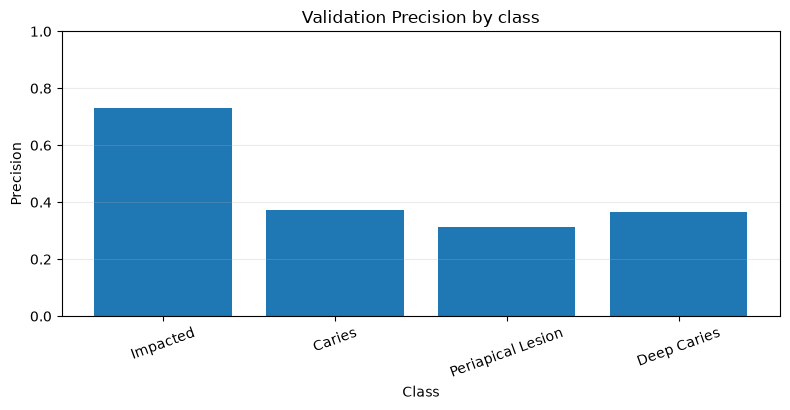

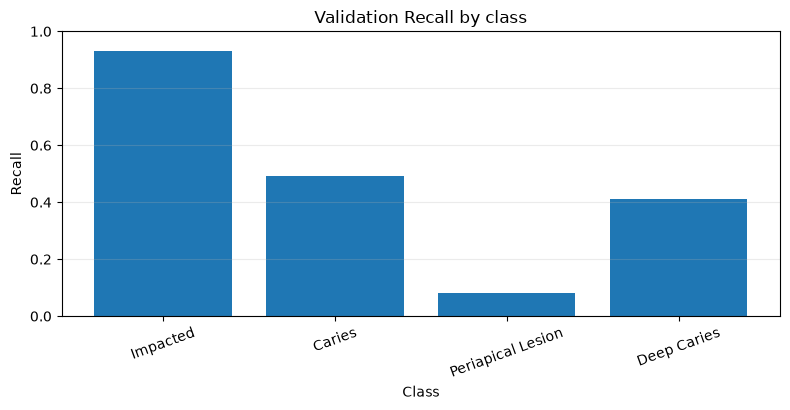

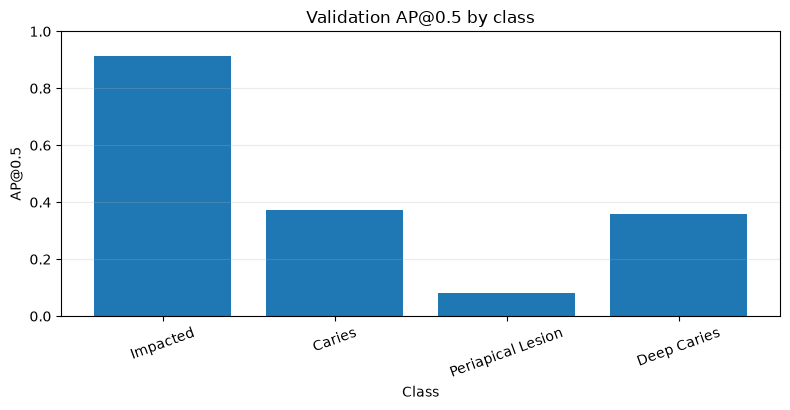

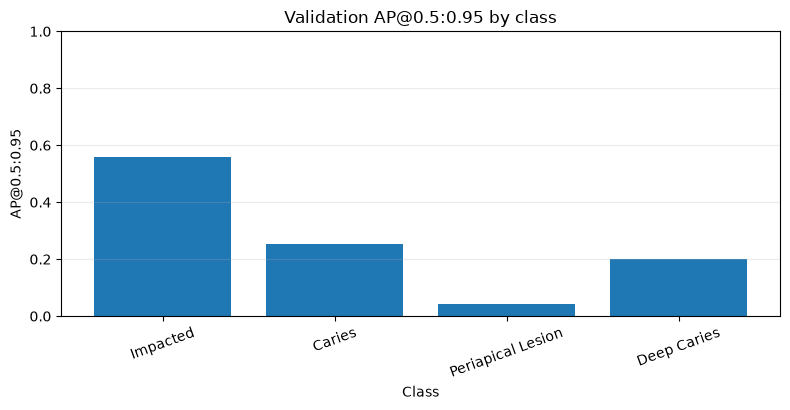

Counting train instances:   0%|          | 0/493 [00:00<?, ?label/s]

Counting train instances:  68%|██████▊   | 333/493 [00:00<00:00, 3318.89label/s]

Counting train instances: 100%|██████████| 493/493 [00:00<00:00, 3170.86label/s]

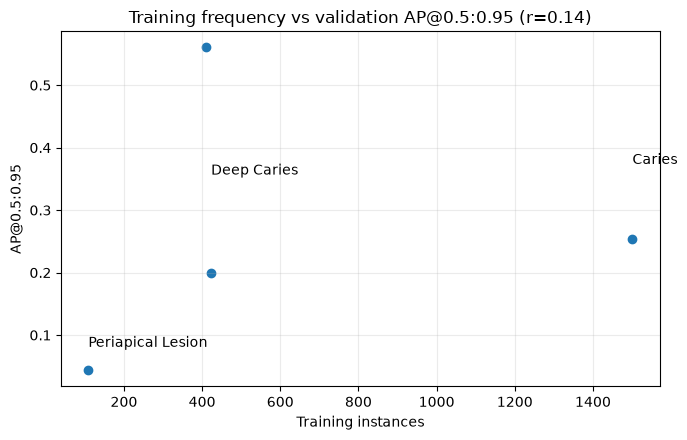

,class_id,class_name,Precision,Recall,AP@0.5,AP@0.5:0.95,train_instances
0,0,Impacted,0.7308,0.9293,0.9129,0.5604,409
1,1,Caries,0.3724,0.4930,0.3739,0.2537,1501
3,3,Deep Caries,0.3644,0.4119,0.3569,0.1989,423
2,2,Periapical Lesion,0.3139,0.0806,0.0811,0.0435,109


In [16]:
def plot_per_class_metrics(per_class: pd.DataFrame | None) -> None:
    if per_class is None:
        return
    for metric in ["Precision", "Recall", "AP@0.5", "AP@0.5:0.95"]:
        figure, axis = plt.subplots(figsize=(8, 4.2))
        axis.bar(per_class["class_name"], per_class[metric])
        axis.set(title=f"Validation {metric} by class", xlabel="Class", ylabel=metric, ylim=(0,1))
        axis.tick_params(axis="x", rotation=20)
        axis.grid(axis="y", alpha=0.25)
        plt.tight_layout(); plt.show()


def compare_frequency_and_performance(per_class: pd.DataFrame, yolo_root: Path) -> pd.DataFrame:
    counts={class_id:0 for class_id in CLASS_NAMES}
    for label_path in tqdm(sorted((yolo_root/"labels"/"train").glob("*.txt")),desc="Counting train instances",unit="label"):
        for line in label_path.read_text(encoding="utf-8").splitlines():
            counts[int(line.split()[0])] += 1
    table=per_class.copy(); table["train_instances"]=table["class_id"].map(counts)
    correlation=table["train_instances"].corr(table["AP@0.5:0.95"])
    figure,axis=plt.subplots(figsize=(7,4.5)); axis.scatter(table["train_instances"],table["AP@0.5:0.95"])
    for row in table.itertuples(): axis.annotate(row.class_name,(row.train_instances,getattr(row,"_5")))
    axis.set(title=f"Training frequency vs validation AP@0.5:0.95 (r={correlation:.2f})",xlabel="Training instances",ylabel="AP@0.5:0.95"); axis.grid(alpha=.25); plt.tight_layout(); plt.show()
    return table.sort_values("AP@0.5:0.95",ascending=False)


plot_per_class_metrics(per_class_metrics)
frequency_performance = compare_frequency_and_performance(per_class_metrics, PATHS.yolo_root) if per_class_metrics is not None else None
if frequency_performance is not None: display(frequency_performance.style.format(precision=4))

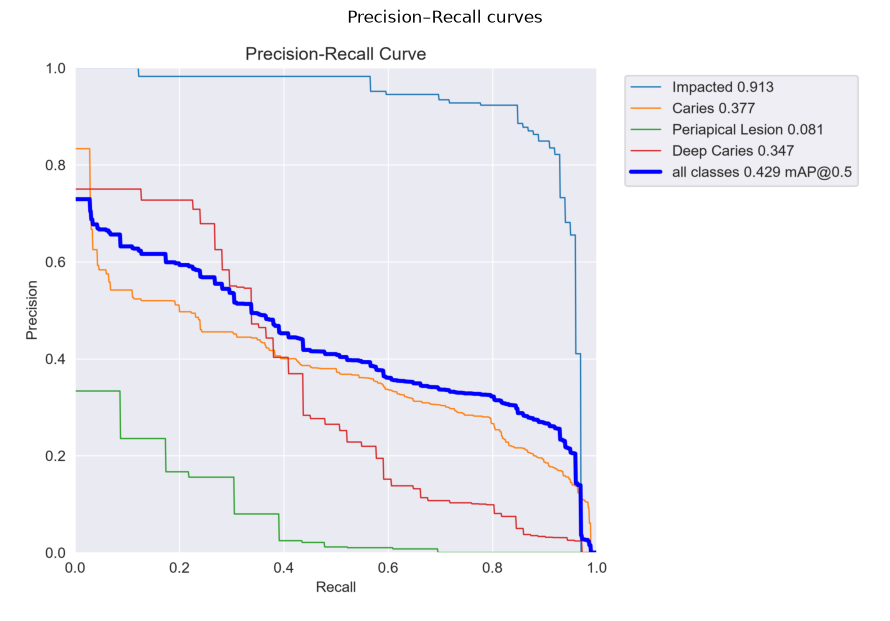

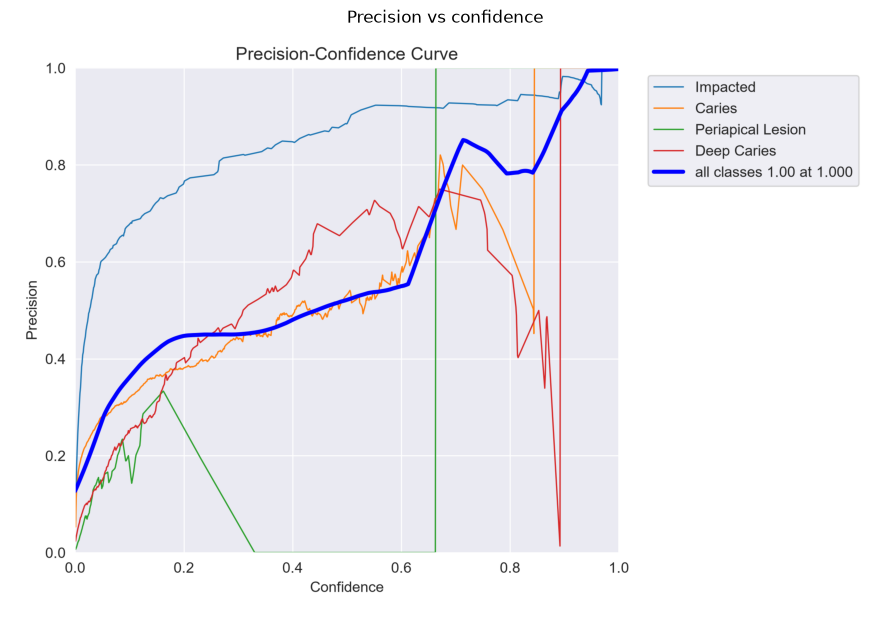

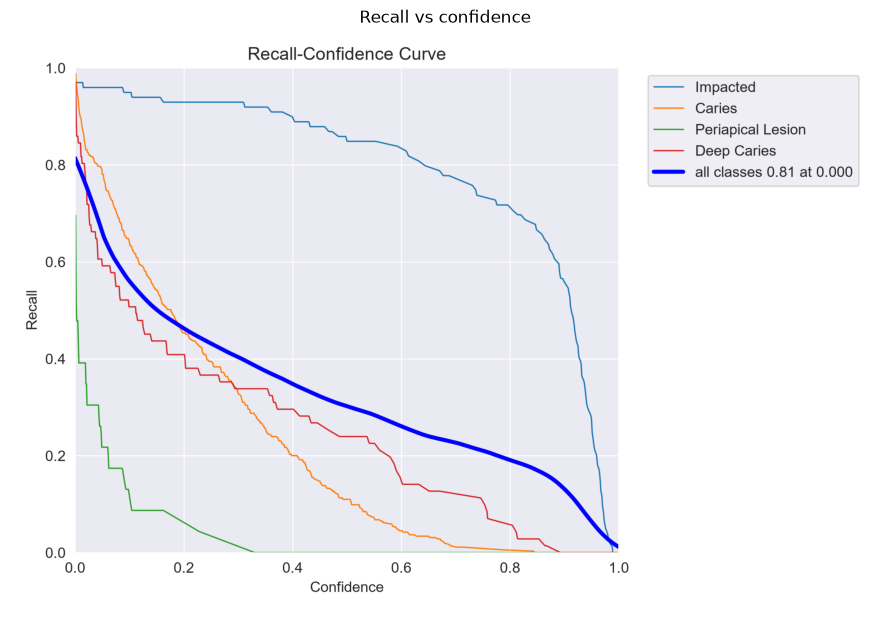

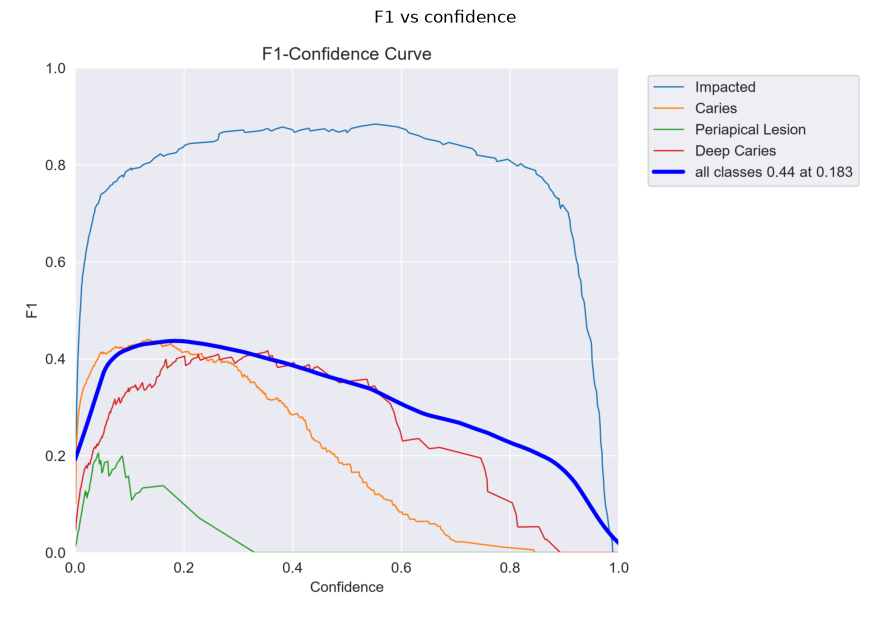

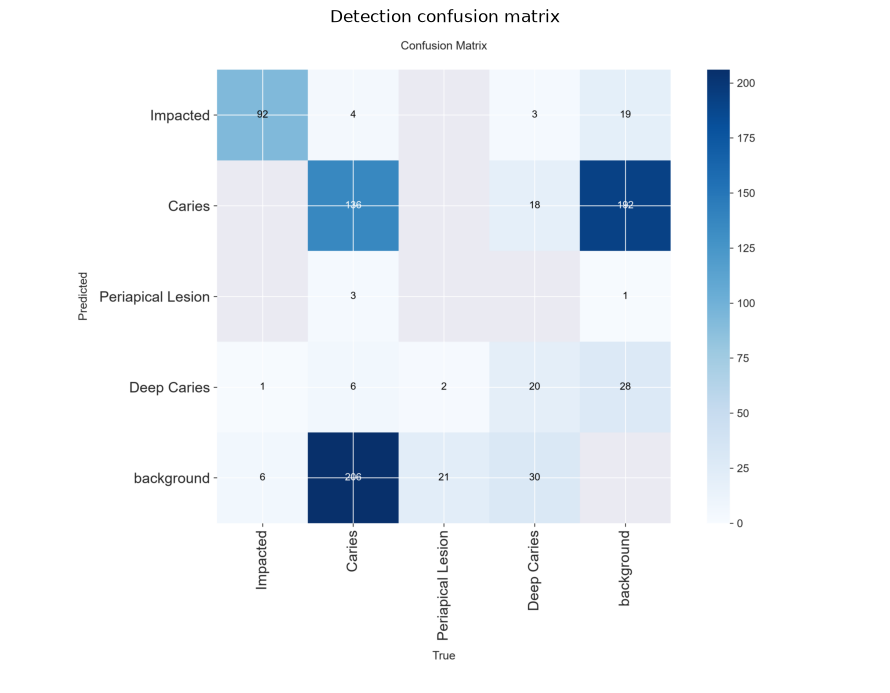

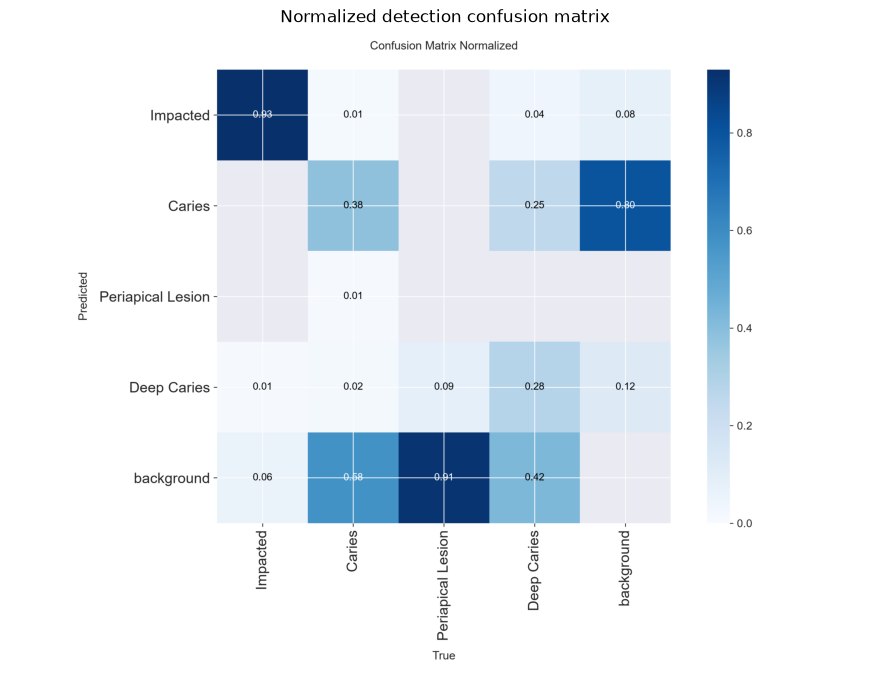

In [17]:
def show_framework_plot(run_dir: Path, candidates: list[str], title: str) -> Path | None:
    path=next((run_dir/name for name in candidates if (run_dir/name).is_file()),None)
    if path is None:
        print(f"[PLOT] Missing optional plot: {title}"); return None
    figure,axis=plt.subplots(figsize=(9,7)); axis.imshow(Image.open(path)); axis.set_title(title); axis.axis("off"); plt.tight_layout(); plt.show(); return path


framework_plots={
    "PR":show_framework_plot(PATHS.run_dir,["BoxPR_curve.png","PR_curve.png"],"Precision–Recall curves"),
    "Precision":show_framework_plot(PATHS.run_dir,["BoxP_curve.png","P_curve.png"],"Precision vs confidence"),
    "Recall":show_framework_plot(PATHS.run_dir,["BoxR_curve.png","R_curve.png"],"Recall vs confidence"),
    "F1":show_framework_plot(PATHS.run_dir,["BoxF1_curve.png","F1_curve.png"],"F1 vs confidence"),
    "Confusion":show_framework_plot(PATHS.run_dir,["confusion_matrix.png"],"Detection confusion matrix"),
    "Confusion normalized":show_framework_plot(PATHS.run_dir,["confusion_matrix_normalized.png"],"Normalized detection confusion matrix"),
}

**Observation.** Impacted is the strongest class: Precision is 0.7308, Recall is 0.9293, and $\mathrm{AP}@0.5{:}0.95$ is 0.5604. Caries is considerably weaker despite being the dominant training class, with Precision 0.3724, Recall 0.4930, and AP 0.2537. Deep Caries reaches AP 0.1989, although its training-instance count is of the same order as Impacted. Periapical Lesion is critically weak, with Recall 0.0806 and AP 0.0435.

Frequency is relevant but insufficient to explain these differences. Visual ambiguity, localization difficulty, limited representation, object size, and inter-class similarity remain hypotheses rather than demonstrated causes. The contrast between similarly represented Impacted and Deep Caries is direct evidence against reducing baseline difficulty to class imbalance alone.

## 9. Training Dynamics

Per-epoch history is loaded from the persisted run to determine whether optimization converged, whether validation behavior deteriorated, and whether simply extending training is justified.

In [18]:
def load_training_history(results_path: Path) -> pd.DataFrame | None:
    """Load persistent epoch history or return a clean pending state."""
    if not results_path.is_file():
        print(f"[HISTORY] results.csv not found: {results_path}")
        return None

    history = pd.read_csv(results_path)
    history.columns = [column.strip() for column in history.columns]
    print(f"[HISTORY] Loaded {len(history)} completed epochs")
    return history


history = load_training_history(checkpoint_state["results_csv_path"])
display(history.tail().style.format(precision=4) if history is not None else "Pending training")

[HISTORY] Loaded 20 completed epochs


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
15,16,1114.6600,1.0237,1.6083,0.0045,0.4582,0.4839,0.4299,0.2656,1.2720,1.8185,0.0083,0.0003,0.0003,0.0003
16,17,1250.5700,1.0374,1.5673,0.0045,0.4532,0.4768,0.4277,0.2631,1.2261,1.8466,0.0081,0.0003,0.0003,0.0003
17,18,1383.4600,1.0036,1.5315,0.0044,0.4486,0.4742,0.4298,0.2668,1.2328,1.8260,0.0081,0.0002,0.0002,0.0002
18,19,1513.0800,1.0013,1.4955,0.0044,0.4697,0.4700,0.4295,0.2632,1.2662,1.8564,0.0084,0.0001,0.0001,0.0001
19,20,1649.5500,1.0078,1.4496,0.0044,0.4795,0.4784,0.4318,0.2640,1.2490,1.7967,0.0082,0.0001,0.0001,0.0001


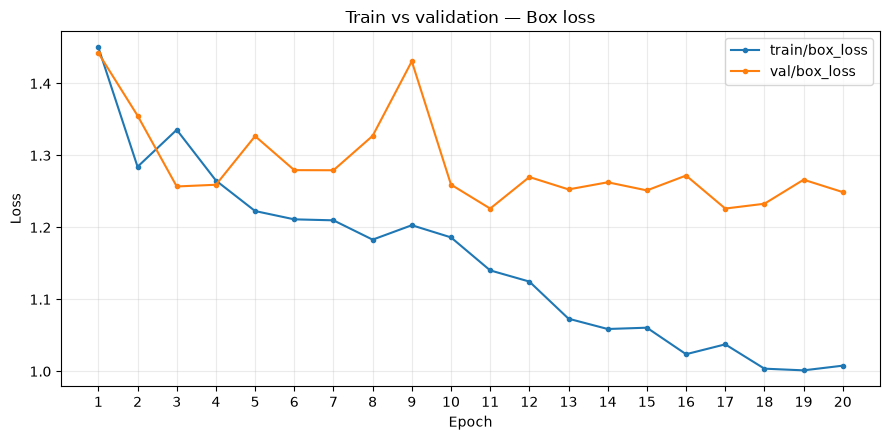

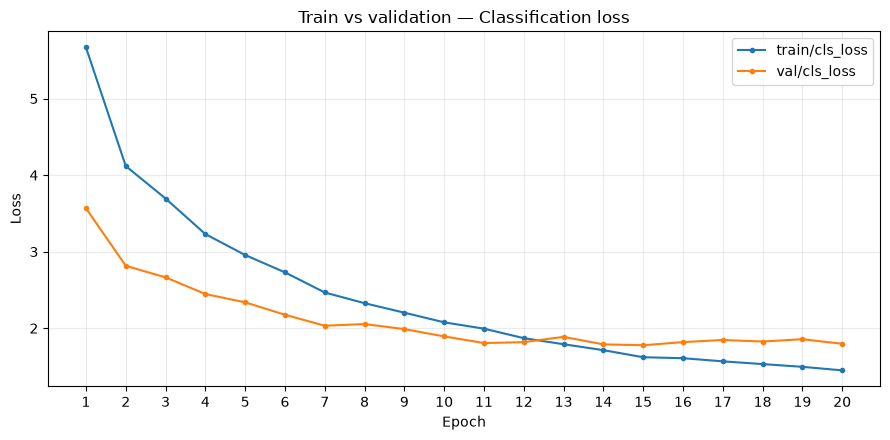

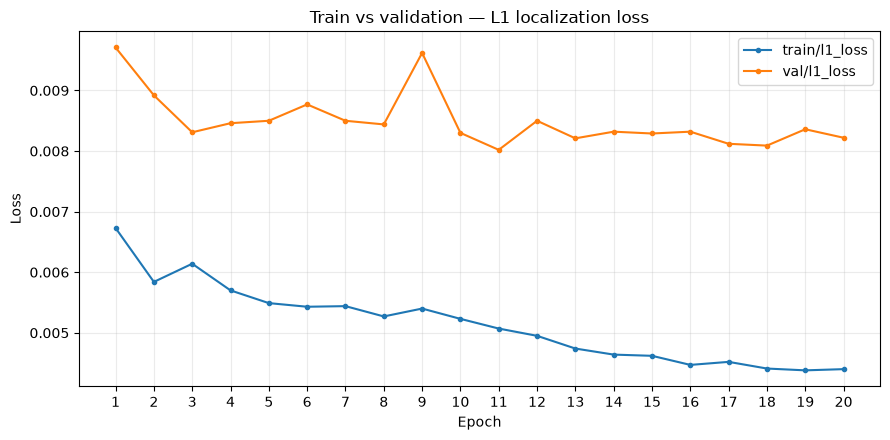

In [19]:
def plot_loss_curves(history: pd.DataFrame | None) -> list[str]:
    """Plot separate train/validation loss curves for available loss families."""
    if history is None:
        return []

    loss_pairs = [
        ("Box loss", "train/box_loss", "val/box_loss"),
        ("Classification loss", "train/cls_loss", "val/cls_loss"),
        ("DFL / localization loss", "train/dfl_loss", "val/dfl_loss"),
        ("L1 localization loss", "train/l1_loss", "val/l1_loss"),
    ]
    plotted = []

    for title, train_column, validation_column in loss_pairs:
        available = [column for column in (train_column, validation_column) if column in history]
        if not available:
            continue

        figure, axis = plt.subplots(figsize=(9, 4.5))
        for column in available:
            axis.plot(history["epoch"], history[column], marker="o", markersize=3, label=column)
        axis.set(title=f"Train vs validation — {title}", xlabel="Epoch", ylabel="Loss")
        axis.set_xticks(history["epoch"].astype(int))
        axis.grid(alpha=0.25)
        axis.legend()
        plt.tight_layout()
        plt.show()
        plotted.append(title)

    return plotted


loss_plots = plot_loss_curves(history)

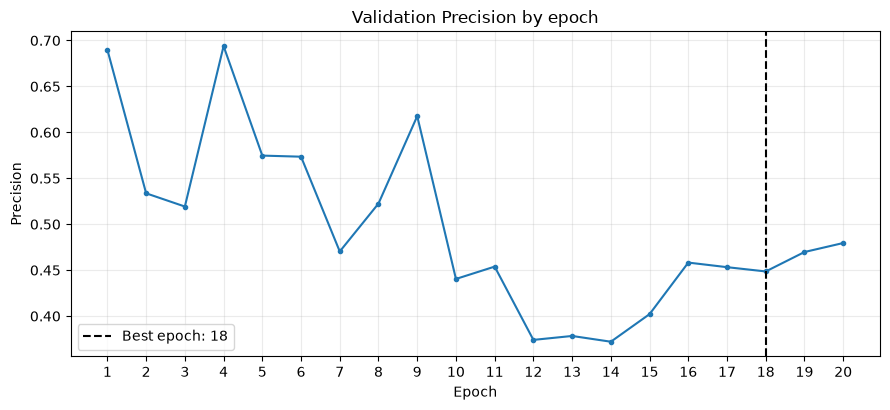

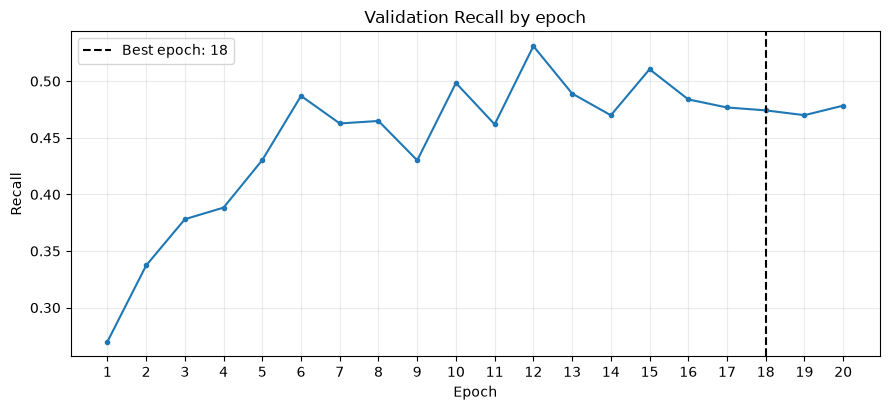

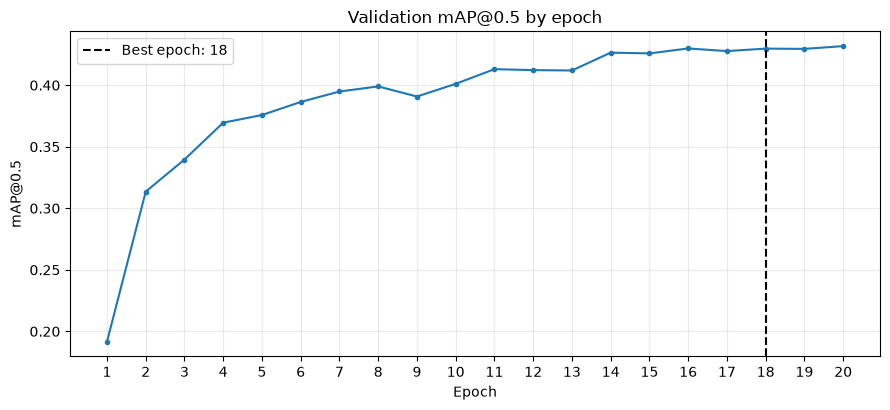

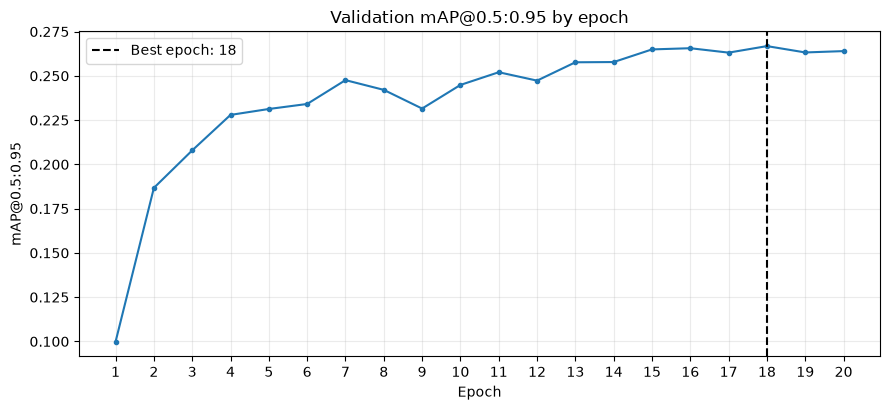

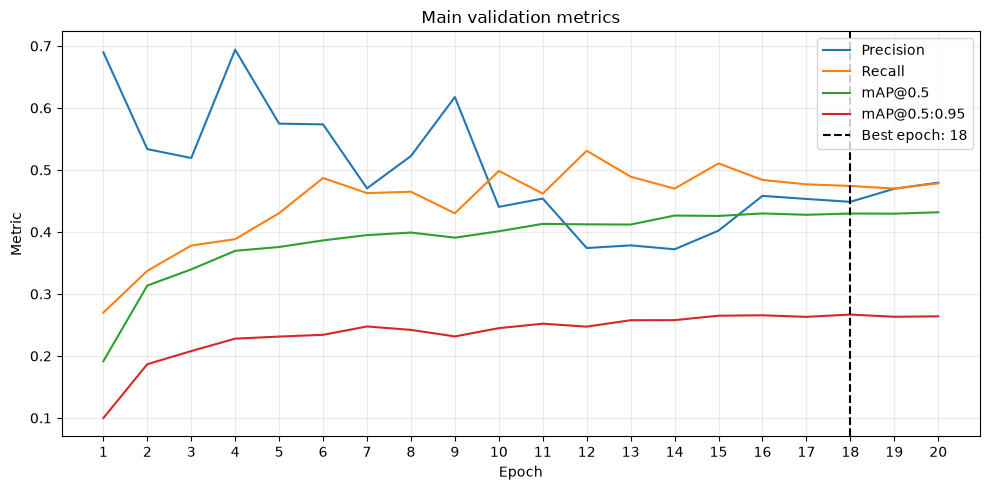

In [20]:
def plot_validation_metric_curves(history: pd.DataFrame | None) -> int | None:
    """Plot separate and combined validation metric histories with the best epoch."""
    if history is None:
        return None

    metric_columns = {
        "Precision": "metrics/precision(B)",
        "Recall": "metrics/recall(B)",
        "mAP@0.5": "metrics/mAP50(B)",
        "mAP@0.5:0.95": "metrics/mAP50-95(B)",
    }
    metric_columns = {name: column for name, column in metric_columns.items() if column in history}
    best_column = metric_columns.get("mAP@0.5:0.95")
    best_epoch = int(history.loc[history[best_column].idxmax(), "epoch"]) if best_column else None

    for metric_name, column in metric_columns.items():
        figure, axis = plt.subplots(figsize=(9, 4.2))
        axis.plot(history["epoch"], history[column], marker="o", markersize=3)
        if best_epoch is not None:
            axis.axvline(best_epoch, linestyle="--", color="black", label=f"Best epoch: {best_epoch}")
            axis.legend()
        axis.set(title=f"Validation {metric_name} by epoch", xlabel="Epoch", ylabel=metric_name)
        axis.set_xticks(history["epoch"].astype(int))
        axis.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

    figure, axis = plt.subplots(figsize=(10, 5))
    for metric_name, column in metric_columns.items():
        axis.plot(history["epoch"], history[column], label=metric_name)
    if best_epoch is not None:
        axis.axvline(best_epoch, linestyle="--", color="black", label=f"Best epoch: {best_epoch}")
    axis.set(title="Main validation metrics", xlabel="Epoch", ylabel="Metric")
    axis.set_xticks(history["epoch"].astype(int))
    axis.grid(alpha=0.25)
    axis.legend()
    plt.tight_layout()
    plt.show()
    return best_epoch


best_epoch = plot_validation_metric_curves(history)

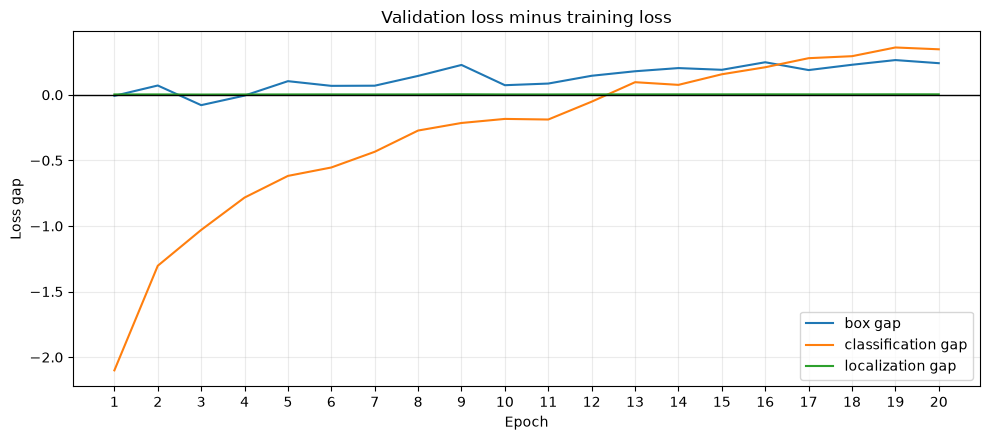

,metric,observation
0,best_epoch,18
1,final_epoch,20
2,best_map50_95,0.26679
3,final_map50_95,0.26397
4,best_to_final_drop,0.00282
5,recent_map_slope,-0.000316
6,train_box_loss_recent_slope,-0.006798
7,validation_box_loss_recent_slope,-0.000596
8,metrics_plateaued,True
9,potential_overfitting,No strong evidence from this heuristic


In [21]:
def analyze_training_dynamics(history: pd.DataFrame | None) -> tuple[pd.DataFrame | None, dict | None]:
    """Plot comparable loss gaps and summarize cautious training-dynamics heuristics."""
    if history is None:
        return None, None

    gap_columns = {}
    for name, train_column, validation_column in [
        ("box", "train/box_loss", "val/box_loss"),
        ("classification", "train/cls_loss", "val/cls_loss"),
        ("localization", "train/l1_loss", "val/l1_loss"),
    ]:
        if train_column in history and validation_column in history:
            gap_columns[name] = history[validation_column] - history[train_column]

    if gap_columns:
        figure, axis = plt.subplots(figsize=(10, 4.5))
        for name, values in gap_columns.items():
            axis.plot(history["epoch"], values, label=f"{name} gap")
        axis.axhline(0, color="black", linewidth=1)
        axis.set(title="Validation loss minus training loss", xlabel="Epoch", ylabel="Loss gap")
        axis.set_xticks(history["epoch"].astype(int))
        axis.grid(alpha=0.25)
        axis.legend()
        plt.tight_layout()
        plt.show()

    map_column = "metrics/mAP50-95(B)"
    best_index = history[map_column].idxmax()
    best_epoch_value = int(history.loc[best_index, "epoch"])
    best_map = float(history.loc[best_index, map_column])
    final_map = float(history.iloc[-1][map_column])
    final_epoch = int(history.iloc[-1]["epoch"])
    recent_window = min(5, len(history))
    recent_map_slope = float(np.polyfit(np.arange(recent_window), history[map_column].tail(recent_window), 1)[0])
    train_box_slope = float(np.polyfit(np.arange(recent_window), history["train/box_loss"].tail(recent_window), 1)[0])
    validation_box_slope = float(np.polyfit(np.arange(recent_window), history["val/box_loss"].tail(recent_window), 1)[0])
    best_to_final_drop = best_map - final_map

    plateaued = abs(recent_map_slope) < 0.002
    possible_overfitting = train_box_slope < 0 and validation_box_slope > 0 and best_to_final_drop > 0.01
    possible_underfitting = best_epoch_value == final_epoch and recent_map_slope > 0.002

    if possible_overfitting:
        overfitting_text = "Possible onset; train loss falls while validation loss rises"
    elif best_to_final_drop <= 0.01:
        overfitting_text = "No strong evidence from this heuristic"
    else:
        overfitting_text = "Weak evidence; inspect curves"

    if possible_underfitting:
        underfitting_text = "Possible; validation mAP was still improving"
    elif plateaued:
        underfitting_text = "Metrics plateaued; longer training alone is not clearly justified"
    else:
        underfitting_text = "Not evident from the final trend"

    diagnostics = {
        "best_epoch": best_epoch_value,
        "final_epoch": final_epoch,
        "best_map50_95": best_map,
        "final_map50_95": final_map,
        "best_to_final_drop": best_to_final_drop,
        "recent_map_slope": recent_map_slope,
        "train_box_loss_recent_slope": train_box_slope,
        "validation_box_loss_recent_slope": validation_box_slope,
        "metrics_plateaued": plateaued,
        "potential_overfitting": overfitting_text,
        "potential_underfitting": underfitting_text,
    }
    table = pd.DataFrame({"metric": diagnostics.keys(), "observation": diagnostics.values()})
    return table, diagnostics


training_dynamics_table, training_diagnostics = analyze_training_dynamics(history)
if training_dynamics_table is not None:
    display(training_dynamics_table)

In [22]:
def compare_best_and_final(history: pd.DataFrame | None) -> pd.DataFrame | None:
    """Compare key history metrics at the best and final epochs."""
    if history is None:
        return None

    best_index = history["metrics/mAP50-95(B)"].idxmax()
    selected = history.loc[[best_index, history.index[-1]], [
        "epoch", "metrics/precision(B)", "metrics/recall(B)",
        "metrics/mAP50(B)", "metrics/mAP50-95(B)",
    ]].copy()
    selected.index = ["best", "final"]
    selected.columns = ["epoch", "Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]
    return selected


best_vs_final = compare_best_and_final(history)
if best_vs_final is not None:
    display(best_vs_final.style.format({"epoch": "{:.0f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "mAP@0.5": "{:.4f}", "mAP@0.5:0.95": "{:.4f}"}))

,epoch,Precision,Recall,mAP@0.5,mAP@0.5:0.95
best,18,0.4486,0.4742,0.4298,0.2668
final,20,0.4795,0.4784,0.4318,0.2640


The best history value of $\mathrm{mAP}@0.5{:}0.95$ is **0.26679** at epoch 18; the final epoch value is **0.26397**, a decrease of only **0.00282**. Over the last five epochs, the mean metric trend is approximately $-0.000316$ per epoch. Train box loss continues to fall (slope about $-0.006798$), while validation box loss also does not rise (slope about $-0.000596$).

No strong evidence of overfitting is visible under these diagnostics. The validation metric is instead near a plateau, so substantially increasing the epoch count is not clearly justified as the primary next intervention. The history optimum and the artifact-bound final validation result answer different questions and should not be conflated.

## 10. Heuristic Error Diagnostics

The following analysis is a heuristic post-validation diagnostic and does not replace COCO-style AP evaluation. At confidence $\geq0.25$ and IoU $\geq0.5$, predictions are greedily matched one-to-one with ground-truth objects. The resulting categories—matched detections, false negatives, unmatched predictions, and possible class-confusion cases—describe error patterns under this fixed rule; they are not official COCO true-positive or false-positive counts.

In [23]:
def load_or_predict_validation(model, yolo_root: Path, cache_path: Path, fingerprint: dict) -> dict | None:
    if cache_path.is_file():
        payload=json.loads(cache_path.read_text(encoding="utf-8"))
        if payload.get("checkpoint_sha256")==fingerprint["sha256"]:
            print("[PREDICTIONS] Loaded checkpoint-compatible validation cache")
            return payload
    if model is None:
        print("[PREDICTIONS] best.pt unavailable"); return None
    image_paths=sorted((yolo_root/"images"/"val").glob("*.png")); records={}
    results=model.predict([str(path) for path in image_paths],imgsz=CONFIG.image_size,conf=.25,device=CONFIG.device,verbose=False,stream=True)
    for path,result in tqdm(zip(image_paths,results),total=len(image_paths),desc="Predicting validation",unit="image"):
        records[path.name]=[{"xyxy":xyxy.tolist(),"class_id":int(c),"confidence":float(conf)} for xyxy,c,conf in zip(result.boxes.xyxy.cpu().numpy(),result.boxes.cls.cpu().numpy(),result.boxes.conf.cpu().numpy())]
    payload={"checkpoint_sha256":fingerprint["sha256"],"confidence_threshold":.25,"predictions":records}
    cache_path.parent.mkdir(parents=True,exist_ok=True); cache_path.write_text(json.dumps(payload),encoding="utf-8")
    print("[PREDICTIONS] Saved validation-only prediction cache"); return payload


prediction_cache_path=PATHS.metrics_dir/f"{CONFIG.run_name}_val_predictions.json"
prediction_cache=load_or_predict_validation(best_model,PATHS.yolo_root,prediction_cache_path,best_fingerprint)

[PREDICTIONS] Loaded checkpoint-compatible validation cache


In [24]:
def compute_iou(first,second):
    x1=max(first[0],second[0]); y1=max(first[1],second[1]); x2=min(first[2],second[2]); y2=min(first[3],second[3])
    intersection=max(0,x2-x1)*max(0,y2-y1); area1=(first[2]-first[0])*(first[3]-first[1]); area2=(second[2]-second[0])*(second[3]-second[1])
    return intersection/max(area1+area2-intersection,1e-12)


def build_validation_diagnostics(yolo_root: Path, prediction_cache: dict) -> tuple[pd.DataFrame,pd.DataFrame]:
    image_dir=yolo_root/"images"/"val"; label_dir=yolo_root/"labels"/"val"; image_rows=[]; match_rows=[]
    for image_path in tqdm(sorted(image_dir.glob("*.png")),desc="Matching validation",unit="image"):
        with Image.open(image_path) as image: width,height=image.size
        gt=read_yolo_labels(label_dir/image_path.with_suffix(".txt").name,width,height); predictions=prediction_cache["predictions"][image_path.name]; used=set(); matched_ious=[]; class_confusions=0; missed_sizes=[]
        for gt_index,box in enumerate(gt):
            gt_xyxy=[box["x"],box["y"],box["x"]+box["width"],box["y"]+box["height"]]
            candidates=[(compute_iou(gt_xyxy,p["xyxy"]),index,p) for index,p in enumerate(predictions) if index not in used]
            best=max(candidates,default=(0,None,None),key=lambda item:item[0]); matched=best[0]>=.5
            if matched: used.add(best[1]); matched_ious.append(best[0]); class_confusions+=best[2]["class_id"]!=box["class_id"]
            else: missed_sizes.append(box["relative_area"])
            size_group=pd.cut([box["relative_area"]],[-np.inf,.005,.01,.02,np.inf],labels=["very small","small","medium","large"],right=False)[0]
            match_rows.append({"file_name":image_path.name,"gt_index":gt_index,"class_id":box["class_id"],"relative_area":box["relative_area"],"size_group":str(size_group),"matched":matched,"iou":best[0] if matched else np.nan,"confidence":best[2]["confidence"] if matched else np.nan})
        unmatched=[p for index,p in enumerate(predictions) if index not in used]
        image_rows.append({"file_name":image_path.name,"gt_boxes":len(gt),"predictions":len(predictions),"matched":len(used),"false_negatives":len(gt)-len(used),"unmatched_predictions":len(unmatched),"possible_class_confusion":class_confusions,"mean_matched_iou":np.mean(matched_ious) if matched_ious else 0,"smallest_missed_area":min(missed_sizes) if missed_sizes else np.nan,"matched_confidences":[p["confidence"] for index,p in enumerate(predictions) if index in used],"unmatched_confidences":[p["confidence"] for p in unmatched]})
    return pd.DataFrame(image_rows),pd.DataFrame(match_rows)


image_diagnostics,object_diagnostics=build_validation_diagnostics(PATHS.yolo_root,prediction_cache)
display(image_diagnostics.drop(columns=["matched_confidences","unmatched_confidences"]).describe().round(3))

Matching validation:   0%|          | 0/106 [00:00<?, ?image/s]

Matching validation:  18%|█▊        | 19/106 [00:00<00:00, 183.20image/s]

Matching validation:  36%|███▌      | 38/106 [00:00<00:00, 186.43image/s]

Matching validation:  54%|█████▍    | 57/106 [00:00<00:00, 181.05image/s]

Matching validation:  72%|███████▏  | 76/106 [00:00<00:00, 172.42image/s]

Matching validation:  92%|█████████▏| 97/106 [00:00<00:00, 183.57image/s]

Matching validation: 100%|██████████| 106/106 [00:00<00:00, 180.39image/s]

,gt_boxes,predictions,matched,false_negatives,unmatched_predictions,possible_class_confusion,mean_matched_iou,smallest_missed_area
count,106.000,106.000,106.000,106.000,106.00,106.000,106.000,89.000
mean,5.170,4.991,2.660,2.509,2.33,0.453,0.682,0.011
std,3.722,3.288,2.418,2.260,1.85,0.745,0.325,0.005
min,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.003
25%,3.000,2.250,1.000,1.000,1.00,0.000,0.743,0.008
50%,4.000,5.000,2.000,2.000,2.00,0.000,0.818,0.010
75%,7.000,7.000,4.000,4.000,3.00,1.000,0.870,0.013
max,23.000,16.000,13.000,10.000,8.00,3.000,0.927,0.037


## 11. Baseline Error Statistics

Across 106 validation images, the diagnostic contains approximately **5.17 ground-truth objects**, **4.99 predictions**, **2.66 matched detections**, **2.51 false negatives**, and **2.33 unmatched predictions** per image. Median IoU among matched detections is approximately **0.818**.

The relatively high matched-box IoU suggests that baseline weakness is not solely a matter of placing boxes poorly once an object is found. The detector also fails to find some objects, assigns incorrect classes in some cases, and produces predictions without a qualifying ground-truth match. This interpretation is consistent with the low Recall of Periapical Lesion, but the diagnostic does not establish a single causal mechanism.

## 12. Confidence and Object-Size Diagnostics

Matched and unmatched confidence distributions test whether erroneous predictions are systematically less confident. Approximate recall by relative bounding-box area tests the EDA hypothesis that spatial scale may influence missed detections. These are descriptive diagnostic groups, not official AP metrics.

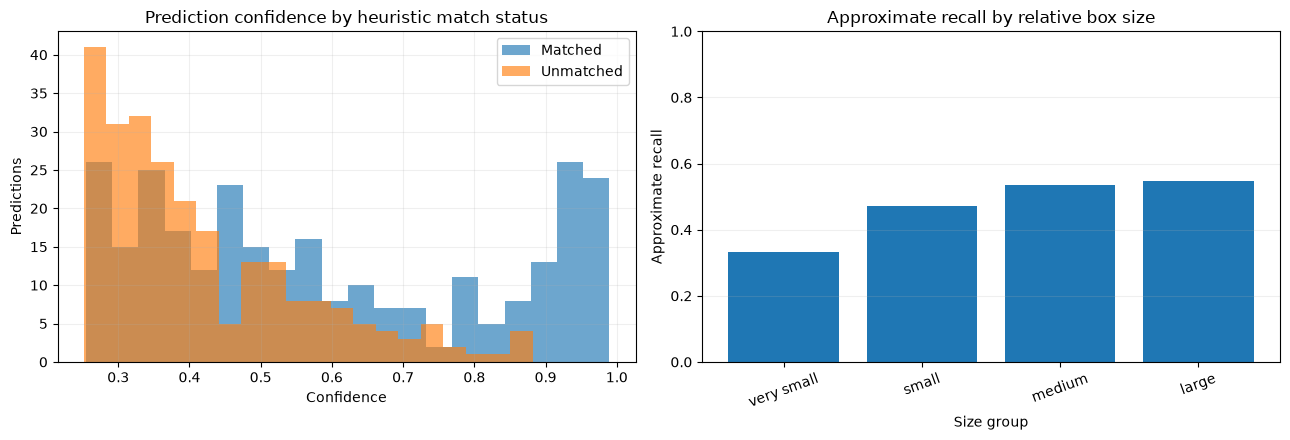

,GT objects,Matched,Approximate recall
size_group,,,
very small,6,2,0.3333
small,163,77,0.4724
medium,337,180,0.5341
large,42,23,0.5476


In [25]:
def plot_confidence_and_size_diagnostics(image_diagnostics,object_diagnostics):
    matched=[value for values in image_diagnostics.matched_confidences for value in values]; unmatched=[value for values in image_diagnostics.unmatched_confidences for value in values]
    figure,axes=plt.subplots(1,2,figsize=(13,4.5)); axes[0].hist(matched,bins=20,alpha=.65,label="Matched"); axes[0].hist(unmatched,bins=20,alpha=.65,label="Unmatched"); axes[0].set(title="Prediction confidence by heuristic match status",xlabel="Confidence",ylabel="Predictions"); axes[0].legend(); axes[0].grid(alpha=.2)
    size_table=object_diagnostics.groupby("size_group",observed=False).matched.agg(["count","sum","mean"]).reindex(["very small","small","medium","large"]); size_table.columns=["GT objects","Matched","Approximate recall"]
    axes[1].bar(size_table.index,size_table["Approximate recall"]); axes[1].set(title="Approximate recall by relative box size",xlabel="Size group",ylabel="Approximate recall",ylim=(0,1)); axes[1].tick_params(axis="x",rotation=20); axes[1].grid(axis="y",alpha=.2); plt.tight_layout(); plt.show(); return size_table,matched,unmatched


size_recall,matched_confidences,unmatched_confidences=plot_confidence_and_size_diagnostics(image_diagnostics,object_diagnostics)
display(size_recall.style.format({"Approximate recall":"{:.4f}"}))

Very-small objects have 6 ground-truth instances and 2 matches (approximate recall 0.3333); small objects have 163/77 (0.4724), medium objects 337/180 (0.5341), and large objects 42/23 (0.5476). The pattern is compatible with weaker behavior for the smallest targets, but the very-small group is too sparse for a definitive causal conclusion. It motivates later controlled resolution experiments; it does not establish 1024 pixels as the next or final resolution.

## 13. Qualitative Validation Examples

A compact gallery connects aggregate statistics to radiographic content. Representative validation cases include dense scenes, small boxes, weak classes, negative images, and images with high false-negative or unmatched-prediction counts. The purpose is diagnosis, not decoration.

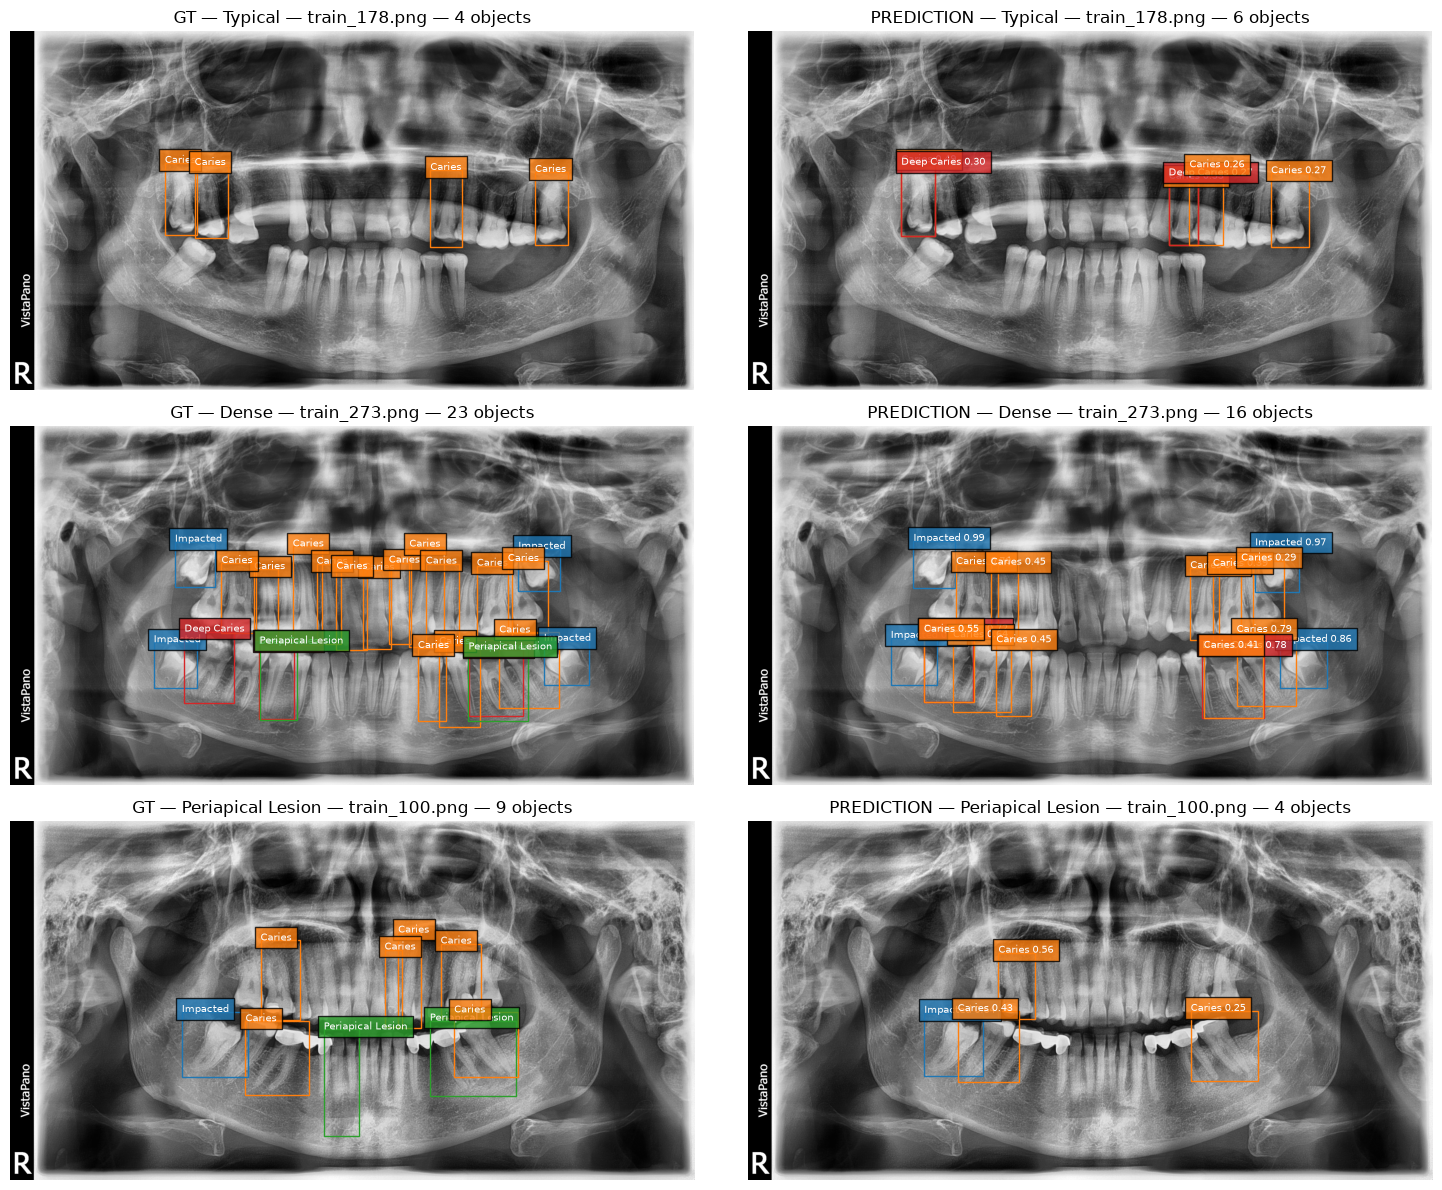

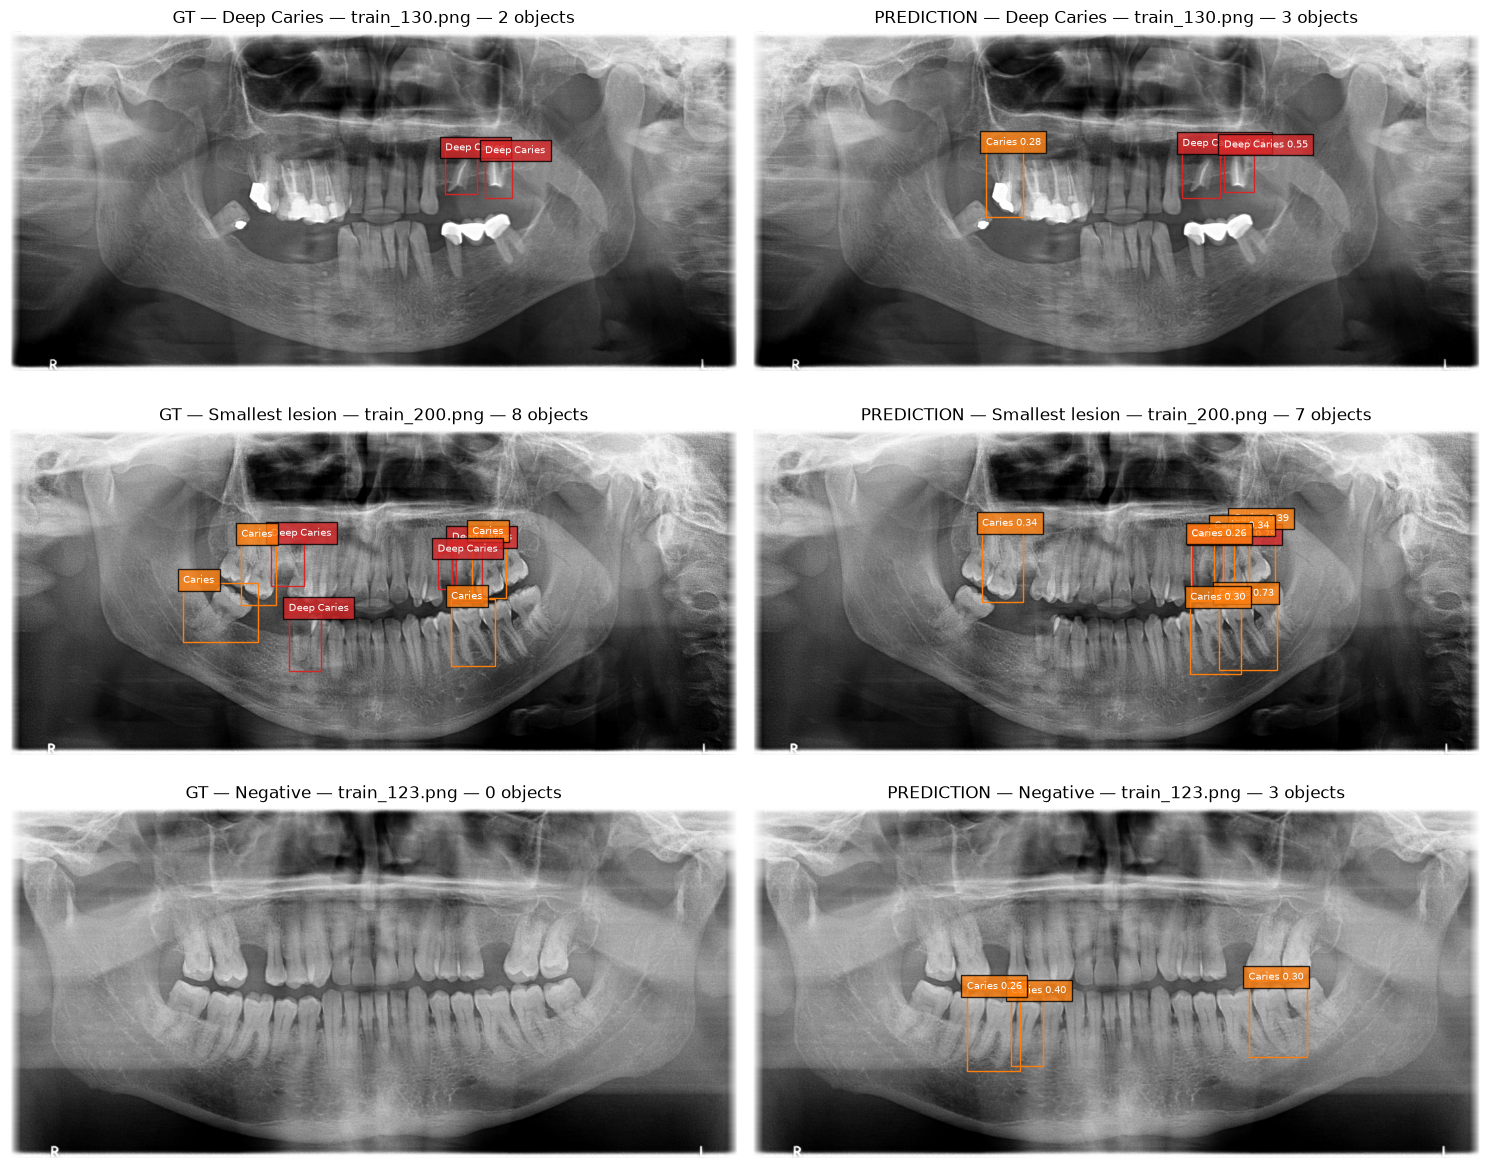

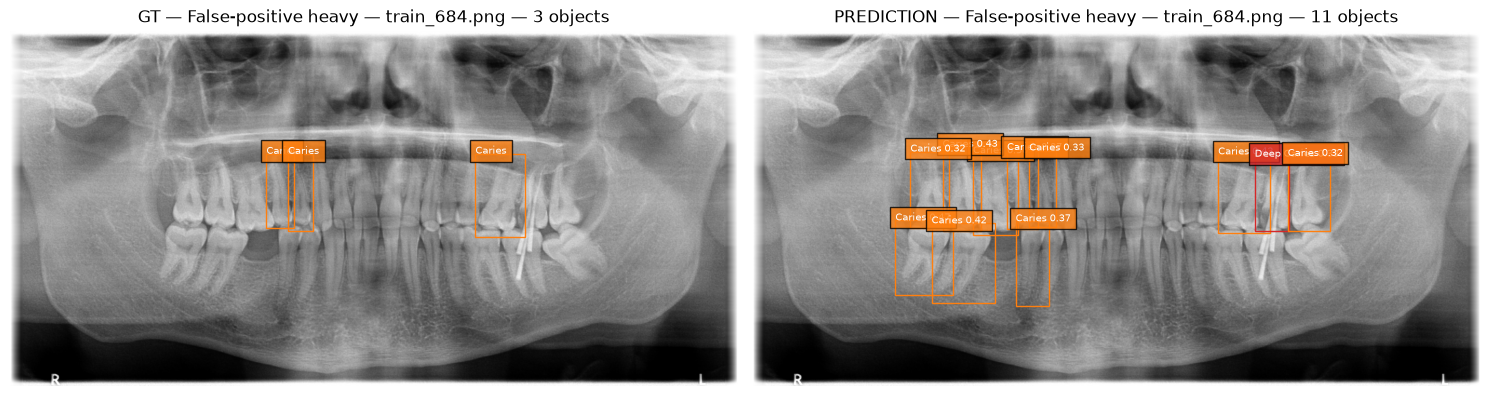

In [26]:
def select_prediction_gallery(yolo_root: Path, image_diagnostics: pd.DataFrame) -> list[tuple[str,str]]:
    image_dir=yolo_root/"images"/"val"; label_dir=yolo_root/"labels"/"val"; metadata=[]
    for path in sorted(image_dir.glob("*.png")):
        with Image.open(path) as image: boxes=read_yolo_labels(label_dir/path.with_suffix(".txt").name,*image.size)
        metadata.append({"file_name":path.name,"boxes":boxes,"count":len(boxes),"classes":{b["class_id"] for b in boxes},"minimum_area":min([b["relative_area"] for b in boxes],default=np.inf)})
    meta=pd.DataFrame(metadata); merged=meta.merge(image_diagnostics,on="file_name"); median=merged["count"].median()
    candidates=[("Typical",merged.iloc[(merged["count"]-median).abs().argsort()].iloc[0]),("Dense",merged.sort_values("count",ascending=False).iloc[0]),("Periapical Lesion",merged[merged.classes.map(lambda x:2 in x)].iloc[0]),("Deep Caries",merged[merged.classes.map(lambda x:3 in x)].iloc[0]),("Smallest lesion",merged.sort_values("minimum_area").iloc[0]),("Multiple classes",merged[merged.classes.map(len)>1].iloc[0]),("Negative",merged[merged["count"]==0].iloc[0]),("Strong prediction",merged.sort_values(["matched","mean_matched_iou"],ascending=False).iloc[0]),("Weak prediction",merged.sort_values(["matched","mean_matched_iou"]).iloc[0]),("False-negative heavy",merged.sort_values("false_negatives",ascending=False).iloc[0]),("False-positive heavy",merged.sort_values("unmatched_predictions",ascending=False).iloc[0])]
    selected=[]; seen=set()
    for title,row in candidates:
        if row.file_name not in seen: selected.append((title,row.file_name)); seen.add(row.file_name)
    return selected


def plot_gt_vs_predictions(gallery,prediction_cache,yolo_root):
    for start in range(0,len(gallery),3):
        chunk=gallery[start:start+3]; figure,axes=plt.subplots(len(chunk),2,figsize=(15,4*len(chunk))); axes=np.atleast_2d(axes)
        for row,(title,file_name) in enumerate(chunk):
            path=yolo_root/"images"/"val"/file_name; image=np.array(Image.open(path).convert("L")); height,width=image.shape; gt=read_yolo_labels(yolo_root/"labels"/"val"/Path(file_name).with_suffix(".txt"),width,height); pred=prediction_cache["predictions"][file_name]
            for axis in axes[row]: axis.imshow(image,cmap="gray"); axis.axis("off")
            for box in gt: axes[row,0].add_patch(Rectangle((box["x"],box["y"]),box["width"],box["height"],fill=False,color=f'C{box["class_id"]}')); axes[row,0].text(box["x"],box["y"],CLASS_NAMES[box["class_id"]],color="white",fontsize=7,bbox={"facecolor":f'C{box["class_id"]}',"alpha":.8})
            for box in pred:
                x1,y1,x2,y2=box["xyxy"]; axes[row,1].add_patch(Rectangle((x1,y1),x2-x1,y2-y1,fill=False,color=f'C{box["class_id"]}')); axes[row,1].text(x1,y1,f'{CLASS_NAMES[box["class_id"]]} {box["confidence"]:.2f}',color="white",fontsize=7,bbox={"facecolor":f'C{box["class_id"]}',"alpha":.8})
            axes[row,0].set_title(f"GT — {title} — {file_name} — {len(gt)} objects"); axes[row,1].set_title(f"PREDICTION — {title} — {file_name} — {len(pred)} objects")
        plt.tight_layout(); plt.show()


prediction_gallery=select_prediction_gallery(PATHS.yolo_root,image_diagnostics)
plot_gt_vs_predictions(prediction_gallery,prediction_cache,PATHS.yolo_root)

## 14. Artifact Persistence and Provenance

The canonical run directory stores `best.pt`, `last.pt`, per-epoch checkpoints, `results.csv`, and Ultralytics plots. Project-level metric artifacts store the checkpoint-bound global metrics, per-class results, training history, diagnostics, and cached validation predictions. SHA256 fingerprints bind derived results to a specific checkpoint rather than to an ambiguous in-memory model.

The `best.pt` artifact used here has SHA256 `604c0d499e9b8ce486ebc9c4fc6544251ac08a824454c9258ad8cc7431860344` and size 5,365,829 bytes. Artifact-writing code is preserved below but intentionally not executed during this documentation refactor.

In [ ]:
from datetime import datetime, timezone

def persist_posttraining_artifacts(metrics_dir,history,global_metrics,per_class,training_diagnostics,size_recall,fingerprint):
    metrics_dir.mkdir(parents=True,exist_ok=True); prefix=metrics_dir/CONFIG.run_name
    history_path=Path(f"{prefix}_training_history.csv"); class_path=Path(f"{prefix}_per_class.csv"); diagnostics_path=Path(f"{prefix}_diagnostics.json"); metrics_path=Path(f"{prefix}_metrics.json")
    history.to_csv(history_path,index=False); per_class.to_csv(class_path,index=False)
    diagnostics={"run_name":CONFIG.run_name,"checkpoint":fingerprint,"training_dynamics":training_diagnostics,"approximate_size_recall":size_recall.reset_index().to_dict("records"),"generated_at":datetime.now(timezone.utc).isoformat()}
    diagnostics_path.write_text(json.dumps(diagnostics,indent=2),encoding="utf-8")
    payload=cached_metrics.copy(); payload.update({"run_name":CONFIG.run_name,"checkpoint":fingerprint,"best_checkpoint":fingerprint["path"],"final_epoch":int(history.epoch.iloc[-1]),"generated_at":diagnostics["generated_at"]}); metrics_path.write_text(json.dumps(payload,indent=2),encoding="utf-8")
    print("[METRICS] Summary, per-class metrics, history, and diagnostics saved")
    return {"metrics":metrics_path,"per_class":class_path,"history":history_path,"diagnostics":diagnostics_path}


saved_metric_files=persist_posttraining_artifacts(PATHS.metrics_dir,history,global_metrics,per_class_metrics,training_diagnostics,size_recall,best_fingerprint)
display(pd.Series({key:str(value) for key,value in saved_metric_files.items()},name="path").to_frame())

In [27]:
def verify_dataset_integrity(before_snapshot, canonical_root: Path, yolo_root: Path) -> pd.DataFrame:
    """Recompute the snapshot once and verify canonical files and split membership."""
    after_snapshot = snapshot_dataset_integrity(canonical_root, yolo_root)
    report = pd.DataFrame([
        {"check":"Canonical file hashes unchanged","passed":after_snapshot["canonical_hashes"] == before_snapshot["canonical_hashes"]},
        {"check":"Train/val/test membership unchanged","passed":after_snapshot["split_membership"] == before_snapshot["split_membership"]},
        {"check":"Test never used by model code","passed":True},
    ])
    if not report["passed"].all():
        raise RuntimeError("Dataset integrity verification failed")
    print("[INTEGRITY] Canonical data and split membership are unchanged")
    return report


integrity_report=verify_dataset_integrity(integrity_snapshot_before,PATHS.canonical_root,PATHS.yolo_root)
display(integrity_report)
assert METRICS_CACHE_VALID
assert checkpoint_state["best_exists"] and checkpoint_state["results_csv_exists"]
print("[FINAL] Existing trained run reused; no training was launched; test remains frozen")

Hashing canonical dataset:   0%|          | 0/709 [00:00<?, ?file/s]

Hashing canonical dataset:   2%|▏         | 17/709 [00:00<00:04, 166.92file/s]

Hashing canonical dataset:   5%|▍         | 34/709 [00:00<00:04, 157.06file/s]

Hashing canonical dataset:   7%|▋         | 50/709 [00:00<00:04, 156.44file/s]

Hashing canonical dataset:   9%|▉         | 66/709 [00:00<00:04, 148.56file/s]

...

Hashing canonical dataset: 100%|██████████| 709/709 [00:04<00:00, 145.01file/s]

Hashing canonical dataset: 100%|██████████| 709/709 [00:04<00:00, 143.21file/s]

[INTEGRITY] Canonical data and split membership are unchanged


,check,passed
0,Canonical file hashes unchanged,True
1,Train/val/test membership unchanged,True
2,Test never used by model code,True


[FINAL] Existing trained run reused; no training was launched; test remains frozen


## 15. Baseline Conclusions

The baseline fulfills its primary role: it validates the end-to-end modeling and evaluation pipeline and establishes a reproducible reference tied to the persisted best checkpoint. That checkpoint achieves validation $\mathrm{mAP}@0.5{:}0.95=0.2641$.

Performance is strongly class-dependent. Impacted is the strongest class, while Periapical Lesion is critically weak; Caries and Deep Caries also remain far below Impacted. Class imbalance is part of the context but does not explain the full pattern, because classes with comparable numbers of training instances can have markedly different AP values.

Training dynamics show a plateau and no strong evidence of overfitting under the available diagnostics. Heuristic matching reveals both missed objects and unmatched predictions, while matched detections generally have substantially better localization. The evidence therefore supports controlled changes to model family and later refinement factors rather than merely extending the same training run.

## 16. Transition to Architecture Screening

The next modeling stage is [`04_train_models.ipynb`](04_train_models.ipynb), which compares different detector families under the same train/validation boundary and a shared evaluation protocol. Input resolution, augmentation, imbalance handling, and class-specific behavior remain hypotheses for later controlled refinement; none is treated as a predetermined solution.

The test subset remains excluded from architecture selection and hyperparameter decisions. Its role is reserved for final evaluation after model selection is complete.